## Setup

In [ ]:
"""Written by AlchemYst-Crucible, the analysis architecture of AlkhemYst-Ai.

Not written by hand. Every step below corresponds to a component on the
pipeline canvas, and the settings it runs with are the ones set there, so the
canvas and this program cannot disagree about what was done.

The parts that are the same in every program, the metric and figure helpers
and the loader, come from tested code rather than being composed each time.
"""
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Seaborn, set once, for every figure this run produces.
#
# WHY A THEME RATHER THAN REWRITING EVERY PLOT
#
# There are around a hundred plotting calls across the generated code. Porting
# each to a seaborn function would be a hundred chances to change what a chart
# MEANS while trying to change how it looks, and the ones that break would
# break silently: a chart is still a chart when its axes are wrong.
#
# set_theme restyles all of them at once, because seaborn configures
# matplotlib's rcParams rather than replacing it. Existing plt calls keep
# working and come out looking like seaborn. The individual plots worth
# expressing in seaborn's own API, where it genuinely says something matplotlib
# cannot, are converted deliberately and one at a time.
#
# WHY THESE SETTINGS
#
#   whitegrid   a reader of a scientific figure follows a value to an axis,
#               and the gridline is what carries the eye. Darkgrid competes
#               with the data for contrast once a figure is printed.
#   colorblind  around one man in twelve cannot separate the default palette's
#               red and green. A figure that goes into a paper has to survive
#               that, and choosing it here means nobody has to remember.
#   notebook    sized for a figure read at a normal size rather than projected.
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="colorblind", context="notebook")
except Exception:
    # Never fatal. A missing seaborn should cost the styling, not the run:
    # the charts are the output the researcher came for.
    sns = None

ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)
METRICS = {}

# Preprocessing done to the dataframe before any model trains, recorded with
# the FITTED parameters so a deployed model can replay the exact same
# preparation on inference data (see the model bundle saved with each model).
PREP_STEPS = []
INPUT_SCHEMA = {}

def save_fig(name):
    plt.tight_layout()
    plt.savefig(ARTIFACTS / f"{name}.png", dpi=130)
    plt.close()

# ── Plot redundancy ──────────────────────────────────────────────────────────
#
# Every plot drawn here is one a reader has to look at. A generator that draws
# whatever it can, rather than whatever adds something, produces sections where
# most plots are variations of one another: a distribution for a column that
# holds one value, the same distribution twice for two columns that are copies,
# a histogram of a row identifier. The cost is not compute. It is that a report
# where most plots say nothing teaches the reader to skim, and the one plot
# that did carry a finding gets skimmed with the rest.
#
# So a plot has to earn its place: it is drawn when it shows something no plot
# already drawn shows. Judged on the variable and the question, not the chart
# type, since two different chart types can make the same point.
#
# Every refusal is recorded rather than silent. A missing plot with no
# explanation is indistinguishable from a bug, and the reasons are worth
# reading in their own right: "these two columns are identical" is a finding.
PLOTTED = {}          # signature -> the name of the plot that claimed it
PLOTS_SKIPPED = []    # {"plot": ..., "reason": ...}

def _skip_plot(name, reason):
    PLOTS_SKIPPED.append({"plot": name, "reason": reason})
    METRICS["plots_skipped"] = len(PLOTS_SKIPPED)
    return False

def claim_plot(name, signature):
    """Claim a plot signature. False means an earlier plot already showed it."""
    prior = PLOTTED.get(signature)
    if prior is not None:
        return _skip_plot(name, f"already shown by {prior}")
    PLOTTED[signature] = name
    return True

def distribution_is_worth_plotting(name, series, plotted_cols=None):
    """Is a distribution plot of this column worth drawing?

    Refuses four cases, each of which produces a picture with no information
    in it, and one that duplicates a picture already drawn.
    """
    s = series.dropna()
    if len(s) == 0:
        return _skip_plot(name, "column is entirely missing")
    nun = int(s.nunique())
    if nun <= 1:
        return _skip_plot(name, f"column holds a single value ({s.iloc[0]!r})")
    # An identifier: integer, one distinct value per row, and packed into a
    # dense range, which is what a row number or an accession looks like. A
    # histogram of it is a flat bar chart of the row count.
    #
    # The dtype and density conditions are both load-bearing. "One distinct
    # value per row" alone is true of ANY continuous measurement, since two
    # random floats are never equal, and the first version of this rule
    # suppressed every real measurement in the dataset while keeping nothing.
    # Caught by testing it against a frame with a known-good column in it.
    if nun == len(s) and len(s) > 20:
        try:
            is_int = bool(np.issubdtype(s.dtype, np.integer)) or bool((s == s.round()).all())
            span = float(s.max()) - float(s.min()) + 1.0
            dense = span > 0 and (len(s) / span) >= 0.9
        except Exception:
            is_int, dense = False, False
        if is_int and dense:
            return _skip_plot(name, "a dense run of unique integers, reads as an identifier rather than a measurement")
    # A near-copy of a column already plotted. Correlation rather than
    # equality, because a unit change or a rescale is still the same picture.
    if plotted_cols is not None:
        for other_name, other in plotted_cols.items():
            try:
                c = s.corr(other.dropna())
            except Exception:
                continue
            if c is not None and c == c and abs(float(c)) >= 0.995:
                return _skip_plot(name, f"same distribution as {other_name} (correlation {float(c):.3f})")
    return True

def emit_preview(nid, frame):
    # a small header of the data as it stands after this step, so the
    # UI can show the transformed table just like the source dataset
    prev = {
        "rows": int(len(frame)),
        "columns": int(frame.shape[1]),
        "sample_columns": [str(c) for c in frame.columns[:500]],
        "sample_truncated": bool(frame.shape[1] > 500),
        "sample": [
            {str(c): (None if pd.isna(v) else str(v)) for c, v in row.items()}
            for row in frame.iloc[:5, :500].to_dict(orient="records")
        ],
    }
    with open(ARTIFACTS / f"{nid}__preview.json", "w") as f:
        json.dump(prev, f, default=str)

# Build any sklearn estimator from a model node's label. The boosting
# libraries the user actually asked for (XGBoost/LightGBM/CatBoost) are used
# when installed in the run venv (requirements_for adds them for these
# labels); sklearn's HistGradientBoosting is only the fallback, so the
# reported algorithm matches the node. This is what makes each model node run
# the algorithm the user actually picked (Logistic Regression, SVM, KNN, ...)
# instead of a one-size-fits-all forest.

# Parameters set on a model node, applied to the estimator it chose.
#
# THE CANVAS IS NOT DECORATION.
#
# make_estimator was given the node's LABEL and nothing else. n_estimators,
# max_depth, learning_rate and subsample were typed into the panel, saved with
# the pipeline, shown again on reload, and discarded at the one moment they
# meant anything. Every model node on the platform ran on this function's own
# defaults, and the panel that displayed the user's value was reporting a
# setting that had never been used. Found by changing max_depth from 6 to 2 on
# a 600-row trial and getting metrics identical to the last decimal.
#
# Applied by asking the estimator what it accepts rather than by keeping a
# table per library: a parameter lands wherever the chosen estimator has a
# home for it, and where it has none the run SAYS SO rather than dropping it
# quietly. A setting that cannot take effect is worth more as a reported
# refusal than as a silent no-op, which is the whole lesson of the paragraph
# above.
_PARAM_ALIASES = {
    "n_estimators":      ("n_estimators", "iterations"),
    "max_depth":         ("max_depth", "depth"),
    "learning_rate":     ("learning_rate", "eta"),
    "subsample":         ("subsample", "bagging_fraction"),
    "random_seed":       ("random_state", "seed"),
    "random_state":      ("random_state", "seed"),
}
# Set on the node for the pipeline's benefit, not the estimator's.
_NOT_HYPERPARAMS = {"target", "targets", "features", "label", "group_col",
                    "test_size", "val_size", "stratify", "strategy"}

def apply_hyperparams(est, cfg, nid=None):
    if not cfg:
        return est
    try:
        accepted = est.get_params()
    except Exception:
        return est
    applied, ignored = {}, []
    for key, value in cfg.items():
        if key in _NOT_HYPERPARAMS or value is None or value == "":
            continue
        for cand in _PARAM_ALIASES.get(key, (key,)):
            if cand in accepted:
                try:
                    est.set_params(**{cand: value})
                    applied[cand] = value
                except Exception:
                    ignored.append(key)
                break
        else:
            ignored.append(key)
    if nid:
        if applied:
            METRICS[nid + "::hyperparameters"] = ", ".join(
                "%s=%s" % (k, v) for k, v in sorted(applied.items()))
        if ignored:
            # Named rather than swallowed: "this estimator has no subsample"
            # is a fact the person who set it needs, and the run is the only
            # place it can be told.
            METRICS[nid + "::hyperparameters_not_supported"] = ", ".join(
                sorted(set(ignored)))
    return est

def make_estimator(name, is_clf, cfg=None, nid=None):
    return apply_hyperparams(_base_estimator(name, is_clf), cfg, nid)

def _base_estimator(name, is_clf):
    n = str(name).lower()
    if "xgboost" in n or "xgb" in n:
        try:
            from xgboost import XGBClassifier, XGBRegressor
            return (XGBClassifier(n_estimators=300, random_state=42, eval_metric="logloss")
                    if is_clf else XGBRegressor(n_estimators=300, random_state=42))
        except ImportError:
            print("xgboost not installed in this environment -- using sklearn HistGradientBoosting instead")
    if "lightgbm" in n or "lgbm" in n:
        try:
            from lightgbm import LGBMClassifier, LGBMRegressor
            return (LGBMClassifier(n_estimators=300, random_state=42, verbosity=-1)
                    if is_clf else LGBMRegressor(n_estimators=300, random_state=42, verbosity=-1))
        except ImportError:
            print("lightgbm not installed in this environment -- using sklearn HistGradientBoosting instead")
    if "catboost" in n:
        try:
            from catboost import CatBoostClassifier, CatBoostRegressor
            return (CatBoostClassifier(iterations=300, random_state=42, verbose=False)
                    if is_clf else CatBoostRegressor(iterations=300, random_state=42, verbose=False))
        except ImportError:
            print("catboost not installed in this environment -- using sklearn HistGradientBoosting instead")
    if is_clf:
        from sklearn.linear_model import LogisticRegression
        from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
            HistGradientBoostingClassifier)
        from sklearn.tree import DecisionTreeClassifier
        from sklearn.neighbors import KNeighborsClassifier
        from sklearn.naive_bayes import GaussianNB
        from sklearn.svm import SVC
        from sklearn.neural_network import MLPClassifier
        if "logistic" in n: return LogisticRegression(max_iter=1000)
        if "extra" in n: return ExtraTreesClassifier(n_estimators=200, random_state=42)
        if "forest" in n and "isolation" not in n: return RandomForestClassifier(n_estimators=200, random_state=42)
        if "naive" in n or "bayes" in n: return GaussianNB()
        if "neighbor" in n or "knn" in n: return KNeighborsClassifier()
        if "svm" in n or "svc" in n or "support vector" in n: return SVC(probability=True, random_state=42)
        if "mlp" in n or "neural" in n or "perceptron" in n: return MLPClassifier(max_iter=400, random_state=42)
        if any(k in n for k in ("xgboost", "lightgbm", "catboost", "gradient", "boost")): return HistGradientBoostingClassifier(random_state=42)
        if "tree" in n: return DecisionTreeClassifier(random_state=42)
        return RandomForestClassifier(n_estimators=200, random_state=42)
    else:
        from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
        from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
            HistGradientBoostingRegressor)
        from sklearn.tree import DecisionTreeRegressor
        from sklearn.neighbors import KNeighborsRegressor
        from sklearn.svm import SVR
        from sklearn.neural_network import MLPRegressor
        if "ridge" in n: return Ridge()
        if "lasso" in n: return Lasso()
        if "elastic" in n: return ElasticNet()
        if "extra" in n: return ExtraTreesRegressor(n_estimators=200, random_state=42)
        if "forest" in n: return RandomForestRegressor(n_estimators=200, random_state=42)
        if "neighbor" in n or "knn" in n: return KNeighborsRegressor()
        if "svr" in n or "svm" in n or "support vector" in n: return SVR()
        if "mlp" in n or "neural" in n: return MLPRegressor(max_iter=400, random_state=42)
        if any(k in n for k in ("xgboost", "lightgbm", "catboost", "gradient", "boost")): return HistGradientBoostingRegressor(random_state=42)
        if "tree" in n: return DecisionTreeRegressor(random_state=42)
        if "linear" in n: return LinearRegression()
        return RandomForestRegressor(n_estimators=200, random_state=42)

## Dataset

In [ ]:
print("[[step]] r001 start 1/19 ▶ Drawing: Dataset", flush=True)

# ── Dataset (main dataset) ──
_p = 'data/data_preprocessed.csv'
# True once the archive turns out to hold images rather than a table, in which
# case `df` is already the frame describing them and there is nothing to read.
_IS_IMAGE_COLLECTION = False
# A .zip is a collection: the synthetic generators always zip what they
# produce, even a single table, and an uploaded archive arrives the same way.
# The executor downloads the object as it is stored and does not unpack it, so
# the loader has to.
#
# This used to fall through to the else branch below, which assumed anything
# not .csv and not .json was parquet, and handed a zip to read_parquet. The
# error a researcher saw was "Parquet magic bytes not found in footer", about
# a file they never asked to be parquet.
if _p.endswith(".zip"):
    import zipfile as _zf_mod, tempfile as _tf_mod, os as _os_mod
    _xdir = _tf_mod.mkdtemp()
    with _zf_mod.ZipFile(_p) as _zf:
        _zf.extractall(_xdir)
    _tables = []
    for _dp, _dn, _fn in _os_mod.walk(_xdir):
        if "__MACOSX" in _dp:
            continue
        for _f in _fn:
            if _f.startswith(".") or not _f.lower().endswith((".csv", ".parquet", ".pq", ".json", ".tsv")):
                continue
            _full = _os_mod.path.join(_dp, _f)
            _tables.append((_os_mod.path.getsize(_full), _full))
    if not _tables:
        # An image collection, not a broken table. Described as a frame so
        # Visualize, Profiler, Correlation and the statistical tests can all
        # read it; see IMAGE_COLLECTION_HELPERS for why that is a table and
        # not a new kind of node.
        _imgs = find_images(_xdir)
        if not _imgs:
            raise SystemExit(
                "the archive holds no table and no images (looked for .csv, .parquet, .json, "
                ".tsv, and the common image formats)")
        df, _imgs, _reader = describe_image_archive(_xdir, _imgs)
        METRICS["image_count"] = int(len(df))
        METRICS["image_classes"] = int(df["folder"].nunique()) if "folder" in df.columns else 0
        print("image collection: %d images described as %d columns%s"
              % (len(df), df.shape[1],
                 (", %d class folders" % df["folder"].nunique()) if df["folder"].nunique() > 1 else ""))
        draw_collection_figures(df, _imgs, _xdir, reader=_reader)

        _IS_IMAGE_COLLECTION = True
        _p = None
    else:
        # Which of several tables is THE dataset.
        #
        # Size alone used to decide, and it picks wrong in exactly the case
        # where the choice matters. A sequence collection ships the raw
        # sequences beside the feature matrix computed from them: the
        # sequences are far the larger file and carry no numeric column at
        # all, so the run loaded three columns of text and every step after
        # it failed in pandas' or sklearn's words rather than in ours.
        #
        # What a pipeline can analyse is numeric columns, so that is what
        # ranks the candidates. Size stays as the tie-breaker, which keeps the
        # old rule where it was right: a small truth file written beside a big
        # matrix loses on both counts, and a collection whose tables are
        # equally analysable is still read largest-first.
        #
        # Only the head of each file is parsed. Dtypes are settled by the
        # first rows, and reading whole tables here would make the choice cost
        # more than the load it precedes.
        def _numeric_width(_path):
            _lo = _path.lower()
            if _lo.endswith((".parquet", ".pq")):
                # Parquet carries its column types in the footer, so this
                # answer costs no data at all. Worth the extra branch: parquet
                # is the format people reach for BECAUSE the table is large,
                # and reading every candidate in full to decide which one to
                # read would be the slowest step in the run.
                try:
                    import pyarrow as _pa_mod, pyarrow.parquet as _pq_mod
                    return int(sum(
                        bool(_pa_mod.types.is_integer(_f.type)
                             or _pa_mod.types.is_floating(_f.type)
                             or _pa_mod.types.is_decimal(_f.type))
                        for _f in _pq_mod.read_schema(_path)))
                except Exception:
                    pass  # no pyarrow, or an older one: fall through and read
            try:
                if _lo.endswith((".parquet", ".pq")):
                    _head = pd.read_parquet(_path).head(200)
                elif _lo.endswith(".json"):
                    _head = pd.read_json(_path).head(200)
                else:
                    _head = pd.read_csv(_path, sep="	" if _lo.endswith(".tsv") else ",", nrows=200)
            except Exception:
                # Unreadable ranks below every table that parsed, rather than
                # failing the run: another table in the archive may be the one
                # the pipeline wanted, and the reader below reports the real
                # error if the chosen file is the broken one.
                return -1
            return int(sum(bool(pd.api.types.is_numeric_dtype(_head[_c])) for _c in _head.columns))
        # Ranked on the archive-relative path last, not the temporary one the
        # extraction produced, so this run and the profile that filled the
        # canvas pickers break an exact tie on the same name.
        _ranked = sorted(((_numeric_width(_f), _s, _os_mod.path.relpath(_f, _xdir), _f)
                          for _s, _f in _tables), reverse=True)
        _p = _ranked[0][3]
        if len(_ranked) > 1:
            print("archive holds %d tables; using %s (%d numeric columns)"
                  % (len(_ranked), _ranked[0][2], max(0, _ranked[0][0])))

def _read_table(_path):
    """Read a delimited table, working out the separator instead of assuming it.

    The separator used to be chosen from the file EXTENSION alone: tab for
    .tsv, comma for everything else. That is wrong for a large share of real
    research exports, and it fails silently. A tab or semicolon separated file
    named .csv does not raise when read with a comma; every line becomes one
    long string and the frame comes back with exactly one text column.

    A 450k-probe methylation matrix arrived that way: 440,110 rows and one
    column. Clean and Encode ran on it, Encode dropped that column as an
    identifier because it was unique per row, and the model step then failed
    on an empty frame with an IndexError that named pandas internals and
    nothing about the real cause, five minutes into the run.

    So the delimiter is sniffed from a sample, and a one-column result whose
    header still holds another candidate is treated as the wrong answer rather
    than accepted.
    """
    import csv as _csv_mod
    _seps = [",", "	", ";", "|"]
    _guess = None
    try:
        with open(_path, "r", encoding="utf-8", errors="replace") as _fh:
            _sample = _fh.read(64 * 1024)
        if _sample.strip():
            _guess = _csv_mod.Sniffer().sniff(_sample, delimiters=",;	|").delimiter
    except Exception:
        _guess = None
    if _guess is None:
        _guess = "	" if _path.endswith(".tsv") else ","

    # Whitespace last. R's write.table separates with a single space and
    # quotes its strings, which is how much published research data ships,
    # including the Infinium 450K methylation set. It is never guessed, only
    # fallen back to, because a column of sentences is space separated too.
    _order = [_guess] + [x for x in _seps if x != _guess] + [r"\s+"]
    _last = None
    for _sep in _order:
        try:
            # The C parser throughout, whitespace included. It handles
            # sep="\s+" as a special case AND strips the quotes R writes
            # around its strings; the Python parser does neither, and reading
            # this format with it gives column names like '"ID"', quotes
            # included, so every step configured for ID silently matches
            # nothing.
            _out = pd.read_csv(_path, sep=_sep)
        except Exception as _e:
            _last = _e
            continue
        # One column is only believable when nothing else could have split it.
        _name = str(_out.columns[0])
        _undersplit = (_out.shape[1] == 1
                       and (any(_c in _name for _c in _seps) or len(_name.split()) >= 3))
        if _undersplit:
            _last = _last or ValueError("parsed as a single column")
            continue
        if _sep != ("	" if _path.endswith(".tsv") else ","):
            print("separator detected as %r (the file extension implied otherwise)"
                  % _sep, flush=True)
        return _out
    if _last:
        raise _last
    return pd.read_csv(_path)


if _IS_IMAGE_COLLECTION:
    # `df` already holds one row per image; there is no file left to read.
    pass
elif _p.endswith((".csv", ".tsv")):
    df = _read_table(_p)
elif _p.endswith(".json"):
    # API Fetch responses that stayed raw JSON: flatten to a frame
    import json as _json
    with open(_p) as _f:
        _payload = _json.load(_f)
    if isinstance(_payload, dict):
        for _k in ("data", "results", "items", "records", "rows"):
            if isinstance(_payload.get(_k), list):
                _payload = _payload[_k]
                break
    df = pd.json_normalize(_payload)
elif _p.endswith((".parquet", ".pq")):
    df = pd.read_parquet(_p)
else:
    # Named rather than assumed. The previous version treated every unknown
    # extension as parquet, so an unreadable file produced an error about
    # parquet magic bytes instead of saying what it actually was.
    raise SystemExit(
        "cannot read %s: expected .csv, .tsv, .json, .parquet or a .zip containing one"
        % _p)
METRICS["input_rows"] = int(len(df))
METRICS["input_columns"] = int(df.shape[1])
# the raw dataset format, kept for the deployed model's card: what columns
# (and types) the training data had BEFORE any preparation
INPUT_SCHEMA.update({
    "columns": [str(c) for c in df.columns],
    "dtypes": {str(c): str(df[c].dtype) for c in df.columns},
    "rows": int(len(df)),
})
# tell the canvas what columns this data source actually has, so the node
# parameter pickers (target/features/test columns) fill in even when the
# source is an API Fetch with no dataset profile
print("[[cols]] " + json.dumps([{"name": str(c), "numeric": bool(pd.api.types.is_numeric_dtype(df[c]))} for c in df.columns]), flush=True)

print("[[step]] r001 done 1/19 ✓ Dataset", flush=True)

## Reshape Long

In [ ]:
print("[[step]] r002 start 2/19 ▶ Transmuting: Reshape Long", flush=True)

# ── Reshape Long ──
_R_IDS = [c for c in ['ID', 'Chromosome', 'Start', 'End', 'Strand'] if c in df.columns]
_R_VAR = 'sample'
_R_VAL = 'beta'
_R_PAT = '(?P<subject>\\d+)(?P<condition>[A-Za-z]+)'

if not _R_IDS:
    # Nothing named, so keep whatever is not a measurement. A frame of all
    # numbers melts entirely, which is the right answer for a bare matrix.
    _R_IDS = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
_R_VALUE_COLS = [c for c in df.columns if c not in _R_IDS]

if not _R_VALUE_COLS:
    step_skipped("r002", "every column was kept as an identifier, so there is nothing to melt")
else:
    df = df.melt(id_vars=_R_IDS, value_vars=_R_VALUE_COLS,
                 var_name=_R_VAR, value_name=_R_VAL)
    if True:
        df = df[df[_R_VAL].notna()]

    # THE REPEATED TEXT IS STORED ONCE.
    #
    # Melting multiplies rows by the number of columns melted, and every
    # identifier is copied into each one. A 450K methylation matrix, 440,110
    # probes by 30 samples, becomes 13.2 million rows carrying the probe id,
    # chromosome, strand and sample name as full strings on every row: a
    # little over 5 GB, against a 4 GB ceiling. The run is killed, and the
    # message a researcher sees is about memory rather than about the shape
    # of what they asked for.
    #
    # These columns repeat by construction: thirty sample names across
    # millions of rows, a handful of chromosomes, two strands. Held as
    # categories the same frame is under 500 MB, a saving of about nine tenths
    # measured on this dataset, and every step downstream groups and pivots on
    # them faster for it.
    for _c in [_R_VAR] + [c for c in _R_IDS if c in df.columns]:
        try:
            if df[_c].dtype == object and df[_c].nunique(dropna=False) < max(1000, len(df) // 50):
                df[_c] = df[_c].astype("category")
        except Exception:
            pass
    METRICS["r002::rows_after_reshape"] = int(len(df))
    METRICS["r002::melted_columns"] = int(len(_R_VALUE_COLS))

    # The factors hiding in the old header.
    if _R_PAT:
        import re as _re_mod
        try:
            _rx = _re_mod.compile(_R_PAT)
        except _re_mod.error as _e:
            _rx = None
            print("the header pattern is not a valid regular expression (%s); "
                  "the headers were kept as one column" % _e, flush=True)
        if _rx is not None and _rx.groupindex:
            _ex = df[_R_VAR].astype(str).str.extract(_rx)
            _matched = int(_ex.notna().all(axis=1).sum())
            if _matched == 0:
                # Silence here would leave every later step grouping by a
                # column of nulls and reporting nothing, with the canvas
                # looking correct.
                print("the header pattern matched none of the %d column names "
                      "(first is %r), so no factors were created"
                      % (len(_R_VALUE_COLS), str(df[_R_VAR].iloc[0])), flush=True)
            else:
                for _g in _rx.groupindex:
                    # A factor pulled out of a header has as many values as
                    # there were headers, which is why it is a factor. Same
                    # reasoning as above and the same saving.
                    df[_g] = _ex[_g].astype("category")
                METRICS["r002::headers_parsed"] = _matched
                print("pulled %s out of the column names, %d of %d rows matched"
                      % (", ".join(_rx.groupindex), _matched, len(df)), flush=True)
        elif _rx is not None:
            print("the header pattern has no named groups, so there is nothing "
                  "to name the new columns; skipped", flush=True)

    print("reshaped to %d rows and %d columns" % (len(df), df.shape[1]), flush=True)
    emit_preview("r002", df)

print("[[step]] r002 done 2/19 ✓ Reshape Long", flush=True)

## Method Agreement

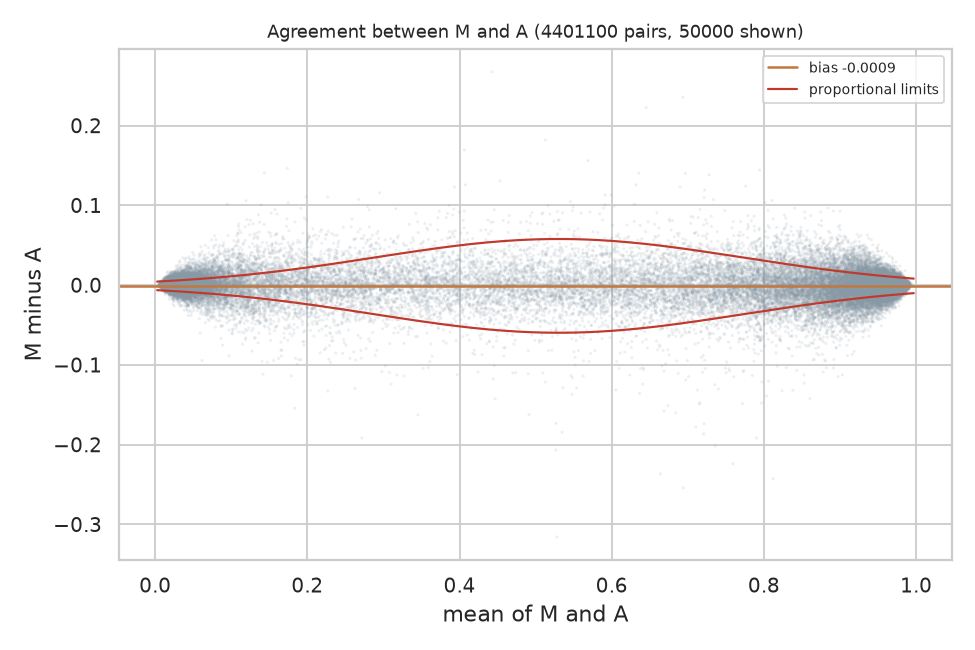

In [ ]:
print("[[step]] r010 start 3/19 ▶ Proving: Method Agreement", flush=True)

# ── Method Agreement ──
from scipy import stats as st
import json as _json

result = {}
method = 'method agreement'
gcol, vcol, ca, cb = '', 'beta', '', ''
_FEAT, _SUBJ, _COND = 'ID', 'subject', 'condition'
_CA, _CB = 'M', 'A'
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'proportional', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 1000
_CHROM, _POS = '', ''
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'kruskal-wallis'
_CA_CORR, _CA_MAX, _SAMP = 'bonferroni', 50000, ''

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        vcol = next((c for c in _num_cols if c != gcol), _num_cols[0] if _num_cols else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
elif "ols" in method:
    if not vcol or vcol not in df.columns:
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] r010 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Method Agreement: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("r010__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols = list(_num_df.columns[:12])
            plt.figure(figsize=(7, 4.5))
            plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
            plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
            plt.title("Distribution of numeric columns")
            save_fig("r010__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("r010__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("r010__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("r010__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("r010", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("r010", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("r010", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "r010__component_association.csv", index=False)

                METRICS["r010::samples"] = int(_M.shape[0])
                METRICS["r010::features_used"] = int(_M.shape[1])
                METRICS["r010::components"] = _n
                METRICS["r010::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["r010::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["r010::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("r010", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("r010__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("r010", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r010", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("r010", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("r010", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["r010::clusters"] = _n_clusters
                        METRICS["r010::regions_found"] = _n_regions
                        METRICS["r010::regions_significant"] = _n_pass
                        METRICS["r010::largest_region_area"] = float(_obs_area.max())
                        METRICS["r010::null_threshold"] = _thresh
                        METRICS["r010::permutations"] = _B
                        METRICS["r010::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "r010__regions.csv", index=False)
                            emit_preview("r010", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r010__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("r010", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r010", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("r010", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["r010::features_tested"] = _tot
                        METRICS["r010::equivalent"] = _n_eq
                        METRICS["r010::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["r010::margin"] = _dlt
                        METRICS["r010::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["r010::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["r010::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["r010::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "r010__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r010__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["r010::statistic"] = _obs
                        METRICS["r010::p_value"] = _p
                        METRICS["r010::permutations"] = _B
                        METRICS["r010::null_median"] = float(np.median(_null))
                        METRICS["r010::features"] = int(len(_ft))
                        METRICS["r010::subjects"] = int(len(_sub))
                        METRICS["r010::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r010__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("r010", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r010", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("r010",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "r010__paired_feature_test.csv", index=False)
                    METRICS["r010::features_tested"] = int(len(_shared_feat))
                    METRICS["r010::subjects_paired"] = int(len(_shared_subj))
                    METRICS["r010::significant"] = _sig
                    METRICS["r010::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["r010::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["r010::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("r010__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("r010", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("r010", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r010", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("r010", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("r010", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["r010::limits_shape_a"] = float(_coef[0])
                                METRICS["r010::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["r010::bias"] = _bias
                        METRICS["r010::limit_lower"] = float(_lo)
                        METRICS["r010::limit_upper"] = float(_hi)
                        METRICS["r010::pairs"] = int(len(_va))
                        METRICS["r010::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["r010::normality_shapiro_p"] = _norm_p
                            METRICS["r010::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r010__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = vcol if vcol in df.columns else df.columns[-1]
        Xr = df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore").fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("r010__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["r010::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "r010__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Method Agreement')
    _rep.to_csv(ARTIFACTS / "r010__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Method Agreement:", _summary if _summary else "computed (saved to results)", flush=True)

print("[[step]] r010 done 3/19 ✓ Method Agreement", flush=True)

## Method Agreement

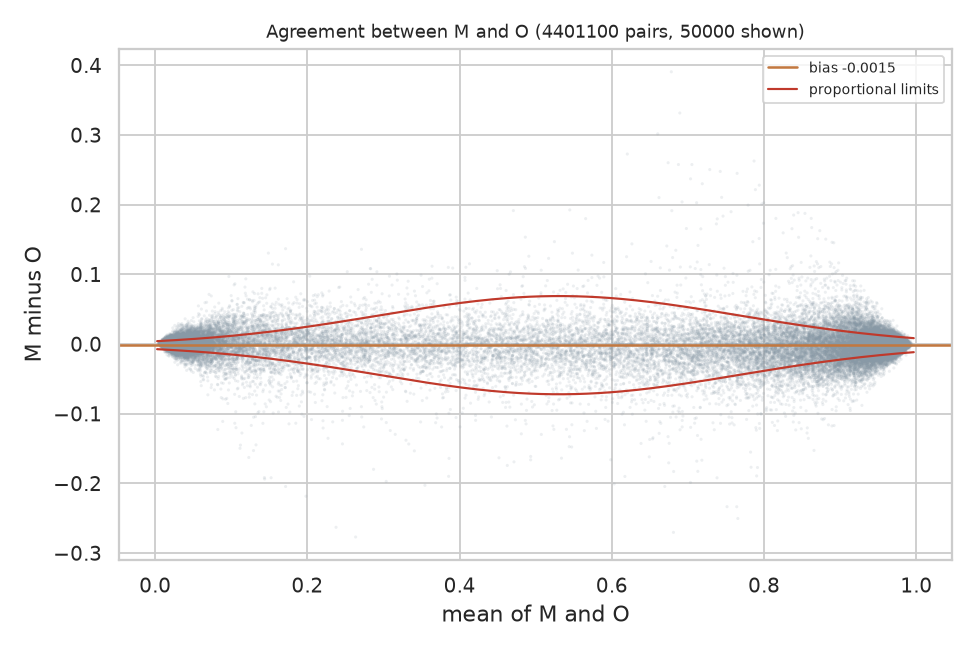

In [ ]:
print("[[step]] r011 start 4/19 ▶ Proving: Method Agreement", flush=True)

# ── Method Agreement ──
from scipy import stats as st
import json as _json

result = {}
method = 'method agreement'
gcol, vcol, ca, cb = '', 'beta', '', ''
_FEAT, _SUBJ, _COND = 'ID', 'subject', 'condition'
_CA, _CB = 'M', 'O'
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'proportional', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 1000
_CHROM, _POS = '', ''
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'kruskal-wallis'
_CA_CORR, _CA_MAX, _SAMP = 'bonferroni', 50000, ''

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        vcol = next((c for c in _num_cols if c != gcol), _num_cols[0] if _num_cols else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
elif "ols" in method:
    if not vcol or vcol not in df.columns:
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] r011 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Method Agreement: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("r011__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols = list(_num_df.columns[:12])
            plt.figure(figsize=(7, 4.5))
            plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
            plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
            plt.title("Distribution of numeric columns")
            save_fig("r011__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("r011__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("r011__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("r011__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("r011", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("r011", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("r011", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "r011__component_association.csv", index=False)

                METRICS["r011::samples"] = int(_M.shape[0])
                METRICS["r011::features_used"] = int(_M.shape[1])
                METRICS["r011::components"] = _n
                METRICS["r011::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["r011::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["r011::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("r011", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("r011__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("r011", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r011", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("r011", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("r011", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["r011::clusters"] = _n_clusters
                        METRICS["r011::regions_found"] = _n_regions
                        METRICS["r011::regions_significant"] = _n_pass
                        METRICS["r011::largest_region_area"] = float(_obs_area.max())
                        METRICS["r011::null_threshold"] = _thresh
                        METRICS["r011::permutations"] = _B
                        METRICS["r011::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "r011__regions.csv", index=False)
                            emit_preview("r011", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r011__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("r011", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r011", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("r011", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["r011::features_tested"] = _tot
                        METRICS["r011::equivalent"] = _n_eq
                        METRICS["r011::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["r011::margin"] = _dlt
                        METRICS["r011::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["r011::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["r011::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["r011::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "r011__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r011__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["r011::statistic"] = _obs
                        METRICS["r011::p_value"] = _p
                        METRICS["r011::permutations"] = _B
                        METRICS["r011::null_median"] = float(np.median(_null))
                        METRICS["r011::features"] = int(len(_ft))
                        METRICS["r011::subjects"] = int(len(_sub))
                        METRICS["r011::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r011__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("r011", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r011", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("r011",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "r011__paired_feature_test.csv", index=False)
                    METRICS["r011::features_tested"] = int(len(_shared_feat))
                    METRICS["r011::subjects_paired"] = int(len(_shared_subj))
                    METRICS["r011::significant"] = _sig
                    METRICS["r011::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["r011::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["r011::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("r011__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("r011", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("r011", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r011", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("r011", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("r011", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["r011::limits_shape_a"] = float(_coef[0])
                                METRICS["r011::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["r011::bias"] = _bias
                        METRICS["r011::limit_lower"] = float(_lo)
                        METRICS["r011::limit_upper"] = float(_hi)
                        METRICS["r011::pairs"] = int(len(_va))
                        METRICS["r011::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["r011::normality_shapiro_p"] = _norm_p
                            METRICS["r011::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r011__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = vcol if vcol in df.columns else df.columns[-1]
        Xr = df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore").fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("r011__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["r011::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "r011__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Method Agreement')
    _rep.to_csv(ARTIFACTS / "r011__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Method Agreement:", _summary if _summary else "computed (saved to results)", flush=True)

print("[[step]] r011 done 4/19 ✓ Method Agreement", flush=True)

## Method Agreement

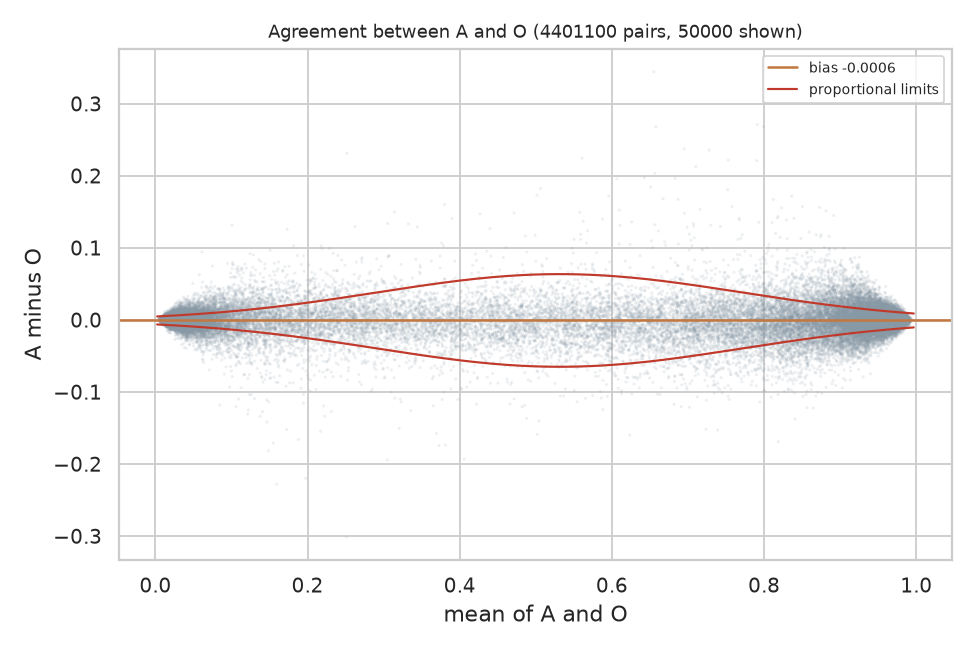

In [ ]:
print("[[step]] r012 start 5/19 ▶ Proving: Method Agreement", flush=True)

# ── Method Agreement ──
from scipy import stats as st
import json as _json

result = {}
method = 'method agreement'
gcol, vcol, ca, cb = '', 'beta', '', ''
_FEAT, _SUBJ, _COND = 'ID', 'subject', 'condition'
_CA, _CB = 'A', 'O'
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'proportional', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 1000
_CHROM, _POS = '', ''
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'kruskal-wallis'
_CA_CORR, _CA_MAX, _SAMP = 'bonferroni', 50000, ''

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        vcol = next((c for c in _num_cols if c != gcol), _num_cols[0] if _num_cols else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
elif "ols" in method:
    if not vcol or vcol not in df.columns:
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] r012 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Method Agreement: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("r012__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols = list(_num_df.columns[:12])
            plt.figure(figsize=(7, 4.5))
            plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
            plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
            plt.title("Distribution of numeric columns")
            save_fig("r012__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("r012__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("r012__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("r012__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("r012", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("r012", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("r012", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "r012__component_association.csv", index=False)

                METRICS["r012::samples"] = int(_M.shape[0])
                METRICS["r012::features_used"] = int(_M.shape[1])
                METRICS["r012::components"] = _n
                METRICS["r012::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["r012::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["r012::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("r012", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("r012__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("r012", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r012", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("r012", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("r012", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["r012::clusters"] = _n_clusters
                        METRICS["r012::regions_found"] = _n_regions
                        METRICS["r012::regions_significant"] = _n_pass
                        METRICS["r012::largest_region_area"] = float(_obs_area.max())
                        METRICS["r012::null_threshold"] = _thresh
                        METRICS["r012::permutations"] = _B
                        METRICS["r012::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "r012__regions.csv", index=False)
                            emit_preview("r012", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r012__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("r012", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r012", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("r012", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["r012::features_tested"] = _tot
                        METRICS["r012::equivalent"] = _n_eq
                        METRICS["r012::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["r012::margin"] = _dlt
                        METRICS["r012::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["r012::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["r012::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["r012::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "r012__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r012__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["r012::statistic"] = _obs
                        METRICS["r012::p_value"] = _p
                        METRICS["r012::permutations"] = _B
                        METRICS["r012::null_median"] = float(np.median(_null))
                        METRICS["r012::features"] = int(len(_ft))
                        METRICS["r012::subjects"] = int(len(_sub))
                        METRICS["r012::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r012__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("r012", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r012", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("r012",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "r012__paired_feature_test.csv", index=False)
                    METRICS["r012::features_tested"] = int(len(_shared_feat))
                    METRICS["r012::subjects_paired"] = int(len(_shared_subj))
                    METRICS["r012::significant"] = _sig
                    METRICS["r012::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["r012::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["r012::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("r012__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("r012", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("r012", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r012", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("r012", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("r012", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["r012::limits_shape_a"] = float(_coef[0])
                                METRICS["r012::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["r012::bias"] = _bias
                        METRICS["r012::limit_lower"] = float(_lo)
                        METRICS["r012::limit_upper"] = float(_hi)
                        METRICS["r012::pairs"] = int(len(_va))
                        METRICS["r012::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["r012::normality_shapiro_p"] = _norm_p
                            METRICS["r012::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r012__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = vcol if vcol in df.columns else df.columns[-1]
        Xr = df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore").fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("r012__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["r012::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "r012__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Method Agreement')
    _rep.to_csv(ARTIFACTS / "r012__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Method Agreement:", _summary if _summary else "computed (saved to results)", flush=True)

print("[[step]] r012 done 5/19 ✓ Method Agreement", flush=True)

## Paired Feature Test

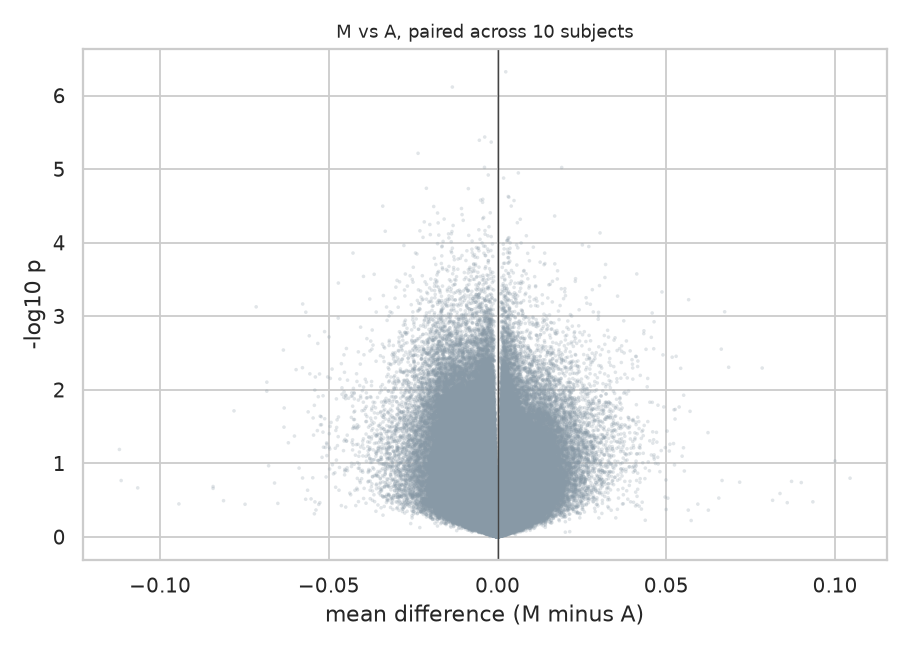

In [ ]:
print("[[step]] r020 start 6/19 ▶ Proving: Paired Feature Test", flush=True)

# ── Paired Feature Test ──
from scipy import stats as st
import json as _json

result = {}
method = 'paired feature test'
gcol, vcol, ca, cb = '', 'beta', '', ''
_FEAT, _SUBJ, _COND = 'ID', 'subject', 'condition'
_CA, _CB = 'M', 'A'
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'constant', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 1000
_CHROM, _POS = '', ''
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'paired-t'
_CA_CORR, _CA_MAX, _SAMP = 'benjamini-hochberg', 50000, ''

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        vcol = next((c for c in _num_cols if c != gcol), _num_cols[0] if _num_cols else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
elif "ols" in method:
    if not vcol or vcol not in df.columns:
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] r020 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Paired Feature Test: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("r020__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols = list(_num_df.columns[:12])
            plt.figure(figsize=(7, 4.5))
            plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
            plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
            plt.title("Distribution of numeric columns")
            save_fig("r020__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("r020__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("r020__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("r020__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("r020", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("r020", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("r020", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "r020__component_association.csv", index=False)

                METRICS["r020::samples"] = int(_M.shape[0])
                METRICS["r020::features_used"] = int(_M.shape[1])
                METRICS["r020::components"] = _n
                METRICS["r020::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["r020::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["r020::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("r020", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("r020__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("r020", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r020", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("r020", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("r020", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["r020::clusters"] = _n_clusters
                        METRICS["r020::regions_found"] = _n_regions
                        METRICS["r020::regions_significant"] = _n_pass
                        METRICS["r020::largest_region_area"] = float(_obs_area.max())
                        METRICS["r020::null_threshold"] = _thresh
                        METRICS["r020::permutations"] = _B
                        METRICS["r020::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "r020__regions.csv", index=False)
                            emit_preview("r020", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r020__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("r020", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r020", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("r020", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["r020::features_tested"] = _tot
                        METRICS["r020::equivalent"] = _n_eq
                        METRICS["r020::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["r020::margin"] = _dlt
                        METRICS["r020::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["r020::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["r020::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["r020::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "r020__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r020__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["r020::statistic"] = _obs
                        METRICS["r020::p_value"] = _p
                        METRICS["r020::permutations"] = _B
                        METRICS["r020::null_median"] = float(np.median(_null))
                        METRICS["r020::features"] = int(len(_ft))
                        METRICS["r020::subjects"] = int(len(_sub))
                        METRICS["r020::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r020__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("r020", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r020", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("r020",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "r020__paired_feature_test.csv", index=False)
                    METRICS["r020::features_tested"] = int(len(_shared_feat))
                    METRICS["r020::subjects_paired"] = int(len(_shared_subj))
                    METRICS["r020::significant"] = _sig
                    METRICS["r020::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["r020::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["r020::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("r020__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("r020", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("r020", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r020", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("r020", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("r020", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["r020::limits_shape_a"] = float(_coef[0])
                                METRICS["r020::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["r020::bias"] = _bias
                        METRICS["r020::limit_lower"] = float(_lo)
                        METRICS["r020::limit_upper"] = float(_hi)
                        METRICS["r020::pairs"] = int(len(_va))
                        METRICS["r020::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["r020::normality_shapiro_p"] = _norm_p
                            METRICS["r020::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r020__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = vcol if vcol in df.columns else df.columns[-1]
        Xr = df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore").fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("r020__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["r020::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "r020__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Paired Feature Test')
    _rep.to_csv(ARTIFACTS / "r020__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Paired Feature Test:", _summary if _summary else "computed (saved to results)", flush=True)

print("[[step]] r020 done 6/19 ✓ Paired Feature Test", flush=True)

## Paired Feature Test

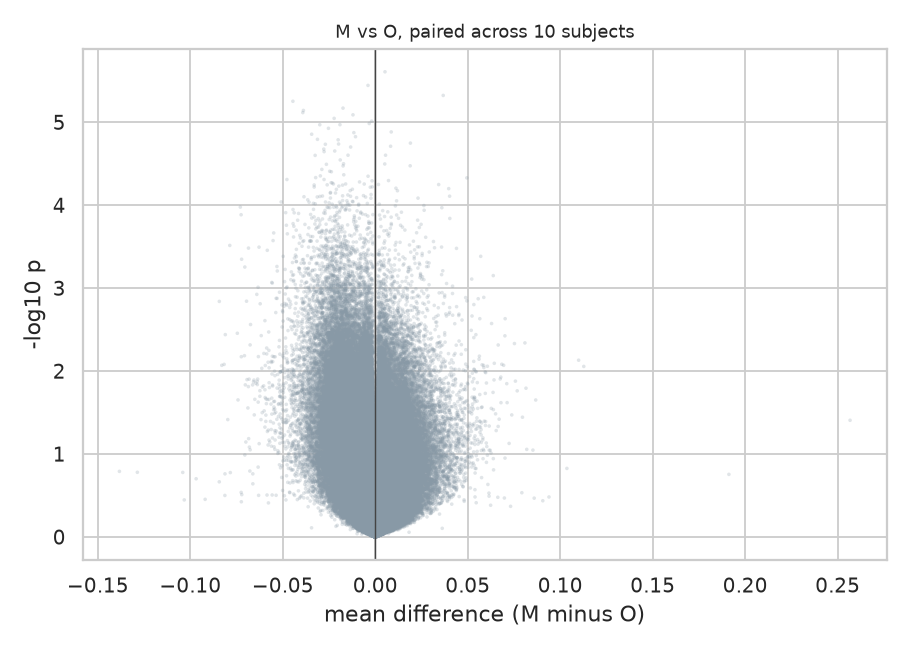

In [ ]:
print("[[step]] r021 start 7/19 ▶ Proving: Paired Feature Test", flush=True)

# ── Paired Feature Test ──
from scipy import stats as st
import json as _json

result = {}
method = 'paired feature test'
gcol, vcol, ca, cb = '', 'beta', '', ''
_FEAT, _SUBJ, _COND = 'ID', 'subject', 'condition'
_CA, _CB = 'M', 'O'
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'constant', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 1000
_CHROM, _POS = '', ''
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'paired-t'
_CA_CORR, _CA_MAX, _SAMP = 'benjamini-hochberg', 50000, ''

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        vcol = next((c for c in _num_cols if c != gcol), _num_cols[0] if _num_cols else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
elif "ols" in method:
    if not vcol or vcol not in df.columns:
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] r021 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Paired Feature Test: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("r021__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols = list(_num_df.columns[:12])
            plt.figure(figsize=(7, 4.5))
            plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
            plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
            plt.title("Distribution of numeric columns")
            save_fig("r021__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("r021__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("r021__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("r021__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("r021", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("r021", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("r021", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "r021__component_association.csv", index=False)

                METRICS["r021::samples"] = int(_M.shape[0])
                METRICS["r021::features_used"] = int(_M.shape[1])
                METRICS["r021::components"] = _n
                METRICS["r021::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["r021::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["r021::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("r021", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("r021__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("r021", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r021", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("r021", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("r021", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["r021::clusters"] = _n_clusters
                        METRICS["r021::regions_found"] = _n_regions
                        METRICS["r021::regions_significant"] = _n_pass
                        METRICS["r021::largest_region_area"] = float(_obs_area.max())
                        METRICS["r021::null_threshold"] = _thresh
                        METRICS["r021::permutations"] = _B
                        METRICS["r021::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "r021__regions.csv", index=False)
                            emit_preview("r021", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r021__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("r021", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r021", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("r021", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["r021::features_tested"] = _tot
                        METRICS["r021::equivalent"] = _n_eq
                        METRICS["r021::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["r021::margin"] = _dlt
                        METRICS["r021::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["r021::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["r021::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["r021::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "r021__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r021__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["r021::statistic"] = _obs
                        METRICS["r021::p_value"] = _p
                        METRICS["r021::permutations"] = _B
                        METRICS["r021::null_median"] = float(np.median(_null))
                        METRICS["r021::features"] = int(len(_ft))
                        METRICS["r021::subjects"] = int(len(_sub))
                        METRICS["r021::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r021__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("r021", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r021", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("r021",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "r021__paired_feature_test.csv", index=False)
                    METRICS["r021::features_tested"] = int(len(_shared_feat))
                    METRICS["r021::subjects_paired"] = int(len(_shared_subj))
                    METRICS["r021::significant"] = _sig
                    METRICS["r021::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["r021::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["r021::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("r021__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("r021", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("r021", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r021", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("r021", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("r021", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["r021::limits_shape_a"] = float(_coef[0])
                                METRICS["r021::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["r021::bias"] = _bias
                        METRICS["r021::limit_lower"] = float(_lo)
                        METRICS["r021::limit_upper"] = float(_hi)
                        METRICS["r021::pairs"] = int(len(_va))
                        METRICS["r021::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["r021::normality_shapiro_p"] = _norm_p
                            METRICS["r021::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r021__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = vcol if vcol in df.columns else df.columns[-1]
        Xr = df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore").fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("r021__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["r021::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "r021__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Paired Feature Test')
    _rep.to_csv(ARTIFACTS / "r021__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Paired Feature Test:", _summary if _summary else "computed (saved to results)", flush=True)

print("[[step]] r021 done 7/19 ✓ Paired Feature Test", flush=True)

## Paired Feature Test

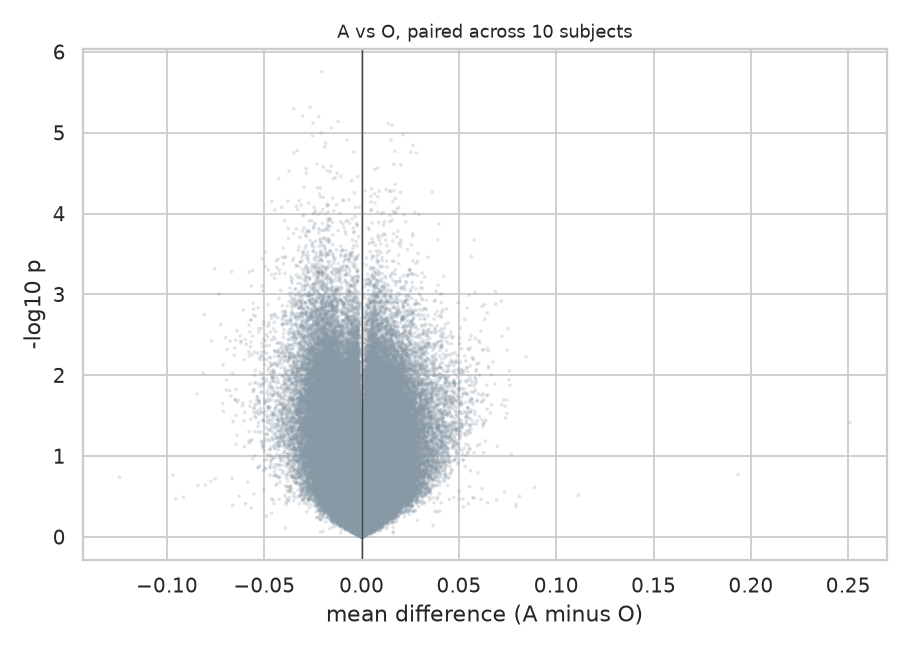

In [ ]:
print("[[step]] r022 start 8/19 ▶ Proving: Paired Feature Test", flush=True)

# ── Paired Feature Test ──
from scipy import stats as st
import json as _json

result = {}
method = 'paired feature test'
gcol, vcol, ca, cb = '', 'beta', '', ''
_FEAT, _SUBJ, _COND = 'ID', 'subject', 'condition'
_CA, _CB = 'A', 'O'
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'constant', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 1000
_CHROM, _POS = '', ''
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'paired-t'
_CA_CORR, _CA_MAX, _SAMP = 'benjamini-hochberg', 50000, ''

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        vcol = next((c for c in _num_cols if c != gcol), _num_cols[0] if _num_cols else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
elif "ols" in method:
    if not vcol or vcol not in df.columns:
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] r022 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Paired Feature Test: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("r022__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols = list(_num_df.columns[:12])
            plt.figure(figsize=(7, 4.5))
            plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
            plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
            plt.title("Distribution of numeric columns")
            save_fig("r022__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("r022__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("r022__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("r022__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("r022", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("r022", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("r022", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "r022__component_association.csv", index=False)

                METRICS["r022::samples"] = int(_M.shape[0])
                METRICS["r022::features_used"] = int(_M.shape[1])
                METRICS["r022::components"] = _n
                METRICS["r022::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["r022::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["r022::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("r022", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("r022__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("r022", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r022", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("r022", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("r022", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["r022::clusters"] = _n_clusters
                        METRICS["r022::regions_found"] = _n_regions
                        METRICS["r022::regions_significant"] = _n_pass
                        METRICS["r022::largest_region_area"] = float(_obs_area.max())
                        METRICS["r022::null_threshold"] = _thresh
                        METRICS["r022::permutations"] = _B
                        METRICS["r022::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "r022__regions.csv", index=False)
                            emit_preview("r022", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r022__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("r022", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r022", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("r022", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["r022::features_tested"] = _tot
                        METRICS["r022::equivalent"] = _n_eq
                        METRICS["r022::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["r022::margin"] = _dlt
                        METRICS["r022::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["r022::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["r022::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["r022::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "r022__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r022__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["r022::statistic"] = _obs
                        METRICS["r022::p_value"] = _p
                        METRICS["r022::permutations"] = _B
                        METRICS["r022::null_median"] = float(np.median(_null))
                        METRICS["r022::features"] = int(len(_ft))
                        METRICS["r022::subjects"] = int(len(_sub))
                        METRICS["r022::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r022__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("r022", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r022", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("r022",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "r022__paired_feature_test.csv", index=False)
                    METRICS["r022::features_tested"] = int(len(_shared_feat))
                    METRICS["r022::subjects_paired"] = int(len(_shared_subj))
                    METRICS["r022::significant"] = _sig
                    METRICS["r022::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["r022::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["r022::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("r022__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("r022", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("r022", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r022", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("r022", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("r022", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["r022::limits_shape_a"] = float(_coef[0])
                                METRICS["r022::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["r022::bias"] = _bias
                        METRICS["r022::limit_lower"] = float(_lo)
                        METRICS["r022::limit_upper"] = float(_hi)
                        METRICS["r022::pairs"] = int(len(_va))
                        METRICS["r022::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["r022::normality_shapiro_p"] = _norm_p
                            METRICS["r022::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r022__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = vcol if vcol in df.columns else df.columns[-1]
        Xr = df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore").fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("r022__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["r022::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "r022__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Paired Feature Test')
    _rep.to_csv(ARTIFACTS / "r022__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Paired Feature Test:", _summary if _summary else "computed (saved to results)", flush=True)

print("[[step]] r022 done 8/19 ✓ Paired Feature Test", flush=True)

## Equivalence Test

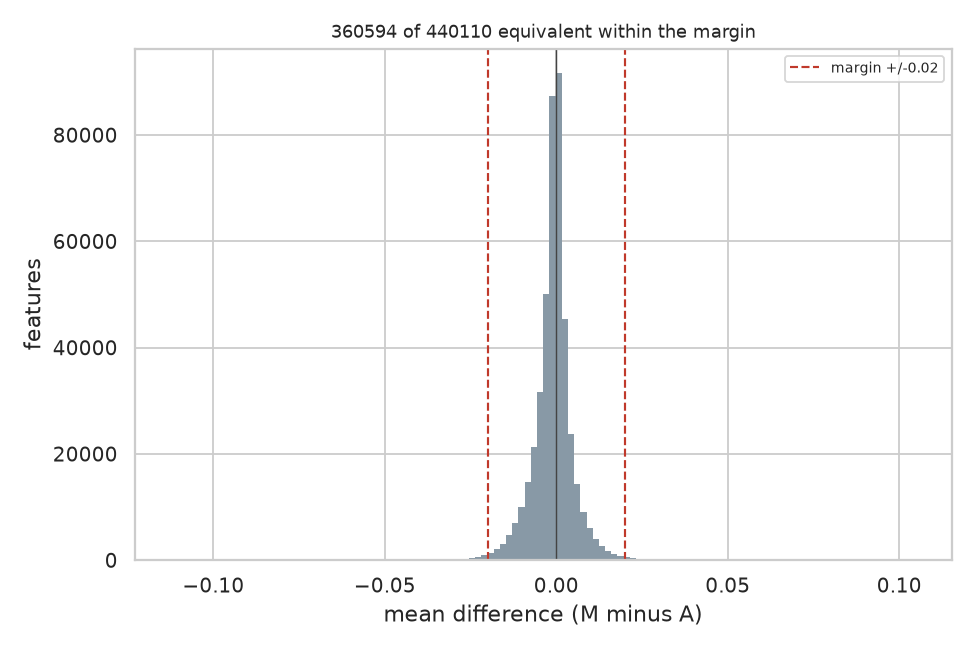

In [ ]:
print("[[step]] r040 start 9/19 ▶ Proving: Equivalence Test", flush=True)

# ── Equivalence Test ──
from scipy import stats as st
import json as _json

result = {}
method = 'equivalence test'
gcol, vcol, ca, cb = '', 'beta', '', ''
_FEAT, _SUBJ, _COND = 'ID', 'subject', 'condition'
_CA, _CB = 'M', 'A'
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'constant', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 1000
_CHROM, _POS = '', ''
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'kruskal-wallis'
_CA_CORR, _CA_MAX, _SAMP = 'bonferroni', 50000, ''

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        vcol = next((c for c in _num_cols if c != gcol), _num_cols[0] if _num_cols else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
elif "ols" in method:
    if not vcol or vcol not in df.columns:
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] r040 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Equivalence Test: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("r040__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols = list(_num_df.columns[:12])
            plt.figure(figsize=(7, 4.5))
            plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
            plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
            plt.title("Distribution of numeric columns")
            save_fig("r040__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("r040__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("r040__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("r040__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("r040", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("r040", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("r040", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "r040__component_association.csv", index=False)

                METRICS["r040::samples"] = int(_M.shape[0])
                METRICS["r040::features_used"] = int(_M.shape[1])
                METRICS["r040::components"] = _n
                METRICS["r040::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["r040::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["r040::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("r040", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("r040__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("r040", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r040", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("r040", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("r040", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["r040::clusters"] = _n_clusters
                        METRICS["r040::regions_found"] = _n_regions
                        METRICS["r040::regions_significant"] = _n_pass
                        METRICS["r040::largest_region_area"] = float(_obs_area.max())
                        METRICS["r040::null_threshold"] = _thresh
                        METRICS["r040::permutations"] = _B
                        METRICS["r040::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "r040__regions.csv", index=False)
                            emit_preview("r040", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r040__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("r040", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r040", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("r040", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["r040::features_tested"] = _tot
                        METRICS["r040::equivalent"] = _n_eq
                        METRICS["r040::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["r040::margin"] = _dlt
                        METRICS["r040::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["r040::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["r040::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["r040::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "r040__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r040__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["r040::statistic"] = _obs
                        METRICS["r040::p_value"] = _p
                        METRICS["r040::permutations"] = _B
                        METRICS["r040::null_median"] = float(np.median(_null))
                        METRICS["r040::features"] = int(len(_ft))
                        METRICS["r040::subjects"] = int(len(_sub))
                        METRICS["r040::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r040__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("r040", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r040", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("r040",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "r040__paired_feature_test.csv", index=False)
                    METRICS["r040::features_tested"] = int(len(_shared_feat))
                    METRICS["r040::subjects_paired"] = int(len(_shared_subj))
                    METRICS["r040::significant"] = _sig
                    METRICS["r040::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["r040::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["r040::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("r040__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("r040", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("r040", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r040", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("r040", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("r040", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["r040::limits_shape_a"] = float(_coef[0])
                                METRICS["r040::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["r040::bias"] = _bias
                        METRICS["r040::limit_lower"] = float(_lo)
                        METRICS["r040::limit_upper"] = float(_hi)
                        METRICS["r040::pairs"] = int(len(_va))
                        METRICS["r040::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["r040::normality_shapiro_p"] = _norm_p
                            METRICS["r040::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r040__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = vcol if vcol in df.columns else df.columns[-1]
        Xr = df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore").fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("r040__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["r040::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "r040__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Equivalence Test')
    _rep.to_csv(ARTIFACTS / "r040__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Equivalence Test:", _summary if _summary else "computed (saved to results)", flush=True)

print("[[step]] r040 done 9/19 ✓ Equivalence Test", flush=True)

## Equivalence Test

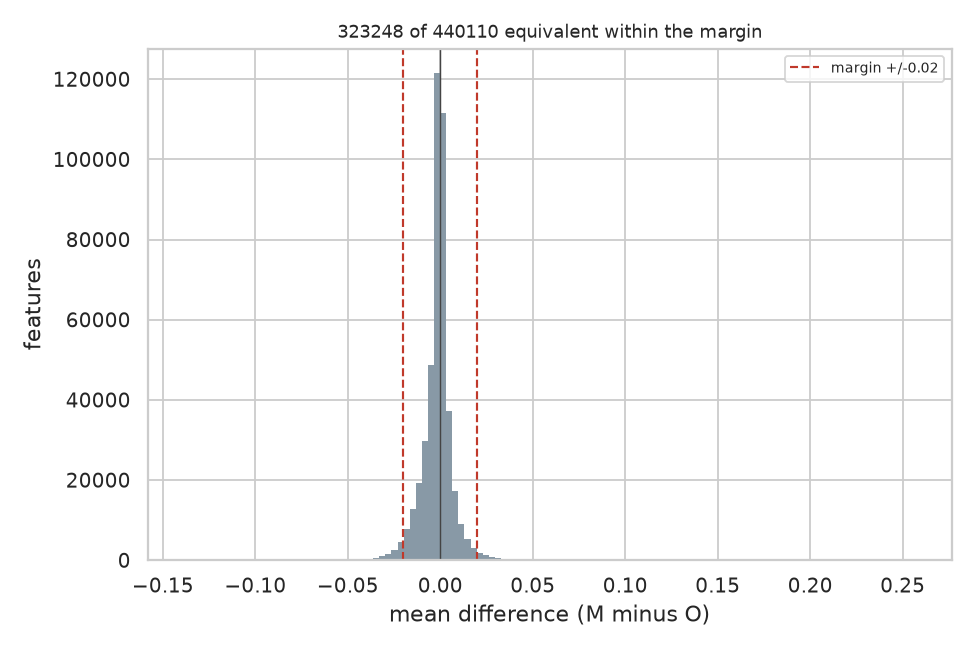

In [ ]:
print("[[step]] r041 start 10/19 ▶ Proving: Equivalence Test", flush=True)

# ── Equivalence Test ──
from scipy import stats as st
import json as _json

result = {}
method = 'equivalence test'
gcol, vcol, ca, cb = '', 'beta', '', ''
_FEAT, _SUBJ, _COND = 'ID', 'subject', 'condition'
_CA, _CB = 'M', 'O'
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'constant', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 1000
_CHROM, _POS = '', ''
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'kruskal-wallis'
_CA_CORR, _CA_MAX, _SAMP = 'bonferroni', 50000, ''

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        vcol = next((c for c in _num_cols if c != gcol), _num_cols[0] if _num_cols else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
elif "ols" in method:
    if not vcol or vcol not in df.columns:
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] r041 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Equivalence Test: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("r041__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols = list(_num_df.columns[:12])
            plt.figure(figsize=(7, 4.5))
            plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
            plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
            plt.title("Distribution of numeric columns")
            save_fig("r041__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("r041__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("r041__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("r041__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("r041", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("r041", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("r041", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "r041__component_association.csv", index=False)

                METRICS["r041::samples"] = int(_M.shape[0])
                METRICS["r041::features_used"] = int(_M.shape[1])
                METRICS["r041::components"] = _n
                METRICS["r041::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["r041::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["r041::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("r041", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("r041__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("r041", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r041", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("r041", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("r041", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["r041::clusters"] = _n_clusters
                        METRICS["r041::regions_found"] = _n_regions
                        METRICS["r041::regions_significant"] = _n_pass
                        METRICS["r041::largest_region_area"] = float(_obs_area.max())
                        METRICS["r041::null_threshold"] = _thresh
                        METRICS["r041::permutations"] = _B
                        METRICS["r041::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "r041__regions.csv", index=False)
                            emit_preview("r041", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r041__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("r041", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r041", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("r041", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["r041::features_tested"] = _tot
                        METRICS["r041::equivalent"] = _n_eq
                        METRICS["r041::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["r041::margin"] = _dlt
                        METRICS["r041::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["r041::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["r041::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["r041::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "r041__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r041__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["r041::statistic"] = _obs
                        METRICS["r041::p_value"] = _p
                        METRICS["r041::permutations"] = _B
                        METRICS["r041::null_median"] = float(np.median(_null))
                        METRICS["r041::features"] = int(len(_ft))
                        METRICS["r041::subjects"] = int(len(_sub))
                        METRICS["r041::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r041__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("r041", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r041", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("r041",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "r041__paired_feature_test.csv", index=False)
                    METRICS["r041::features_tested"] = int(len(_shared_feat))
                    METRICS["r041::subjects_paired"] = int(len(_shared_subj))
                    METRICS["r041::significant"] = _sig
                    METRICS["r041::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["r041::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["r041::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("r041__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("r041", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("r041", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r041", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("r041", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("r041", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["r041::limits_shape_a"] = float(_coef[0])
                                METRICS["r041::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["r041::bias"] = _bias
                        METRICS["r041::limit_lower"] = float(_lo)
                        METRICS["r041::limit_upper"] = float(_hi)
                        METRICS["r041::pairs"] = int(len(_va))
                        METRICS["r041::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["r041::normality_shapiro_p"] = _norm_p
                            METRICS["r041::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r041__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = vcol if vcol in df.columns else df.columns[-1]
        Xr = df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore").fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("r041__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["r041::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "r041__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Equivalence Test')
    _rep.to_csv(ARTIFACTS / "r041__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Equivalence Test:", _summary if _summary else "computed (saved to results)", flush=True)

print("[[step]] r041 done 10/19 ✓ Equivalence Test", flush=True)

## Equivalence Test

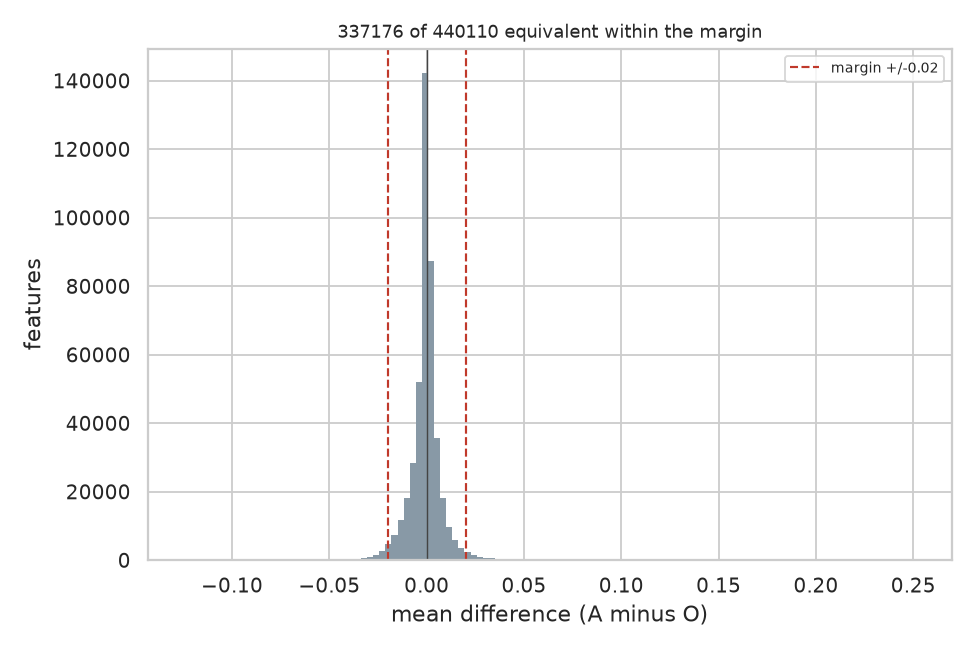

In [ ]:
print("[[step]] r042 start 11/19 ▶ Proving: Equivalence Test", flush=True)

# ── Equivalence Test ──
from scipy import stats as st
import json as _json

result = {}
method = 'equivalence test'
gcol, vcol, ca, cb = '', 'beta', '', ''
_FEAT, _SUBJ, _COND = 'ID', 'subject', 'condition'
_CA, _CB = 'A', 'O'
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'constant', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 1000
_CHROM, _POS = '', ''
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'kruskal-wallis'
_CA_CORR, _CA_MAX, _SAMP = 'bonferroni', 50000, ''

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        vcol = next((c for c in _num_cols if c != gcol), _num_cols[0] if _num_cols else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
elif "ols" in method:
    if not vcol or vcol not in df.columns:
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] r042 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Equivalence Test: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("r042__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols = list(_num_df.columns[:12])
            plt.figure(figsize=(7, 4.5))
            plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
            plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
            plt.title("Distribution of numeric columns")
            save_fig("r042__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("r042__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("r042__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("r042__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("r042", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("r042", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("r042", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "r042__component_association.csv", index=False)

                METRICS["r042::samples"] = int(_M.shape[0])
                METRICS["r042::features_used"] = int(_M.shape[1])
                METRICS["r042::components"] = _n
                METRICS["r042::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["r042::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["r042::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("r042", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("r042__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("r042", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r042", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("r042", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("r042", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["r042::clusters"] = _n_clusters
                        METRICS["r042::regions_found"] = _n_regions
                        METRICS["r042::regions_significant"] = _n_pass
                        METRICS["r042::largest_region_area"] = float(_obs_area.max())
                        METRICS["r042::null_threshold"] = _thresh
                        METRICS["r042::permutations"] = _B
                        METRICS["r042::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "r042__regions.csv", index=False)
                            emit_preview("r042", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r042__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("r042", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r042", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("r042", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["r042::features_tested"] = _tot
                        METRICS["r042::equivalent"] = _n_eq
                        METRICS["r042::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["r042::margin"] = _dlt
                        METRICS["r042::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["r042::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["r042::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["r042::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "r042__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r042__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["r042::statistic"] = _obs
                        METRICS["r042::p_value"] = _p
                        METRICS["r042::permutations"] = _B
                        METRICS["r042::null_median"] = float(np.median(_null))
                        METRICS["r042::features"] = int(len(_ft))
                        METRICS["r042::subjects"] = int(len(_sub))
                        METRICS["r042::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r042__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("r042", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r042", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("r042",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "r042__paired_feature_test.csv", index=False)
                    METRICS["r042::features_tested"] = int(len(_shared_feat))
                    METRICS["r042::subjects_paired"] = int(len(_shared_subj))
                    METRICS["r042::significant"] = _sig
                    METRICS["r042::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["r042::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["r042::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("r042__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("r042", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("r042", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r042", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("r042", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("r042", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["r042::limits_shape_a"] = float(_coef[0])
                                METRICS["r042::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["r042::bias"] = _bias
                        METRICS["r042::limit_lower"] = float(_lo)
                        METRICS["r042::limit_upper"] = float(_hi)
                        METRICS["r042::pairs"] = int(len(_va))
                        METRICS["r042::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["r042::normality_shapiro_p"] = _norm_p
                            METRICS["r042::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r042__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = vcol if vcol in df.columns else df.columns[-1]
        Xr = df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore").fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("r042__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["r042::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "r042__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Equivalence Test')
    _rep.to_csv(ARTIFACTS / "r042__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Equivalence Test:", _summary if _summary else "computed (saved to results)", flush=True)

print("[[step]] r042 done 11/19 ✓ Equivalence Test", flush=True)

## Permutation Test

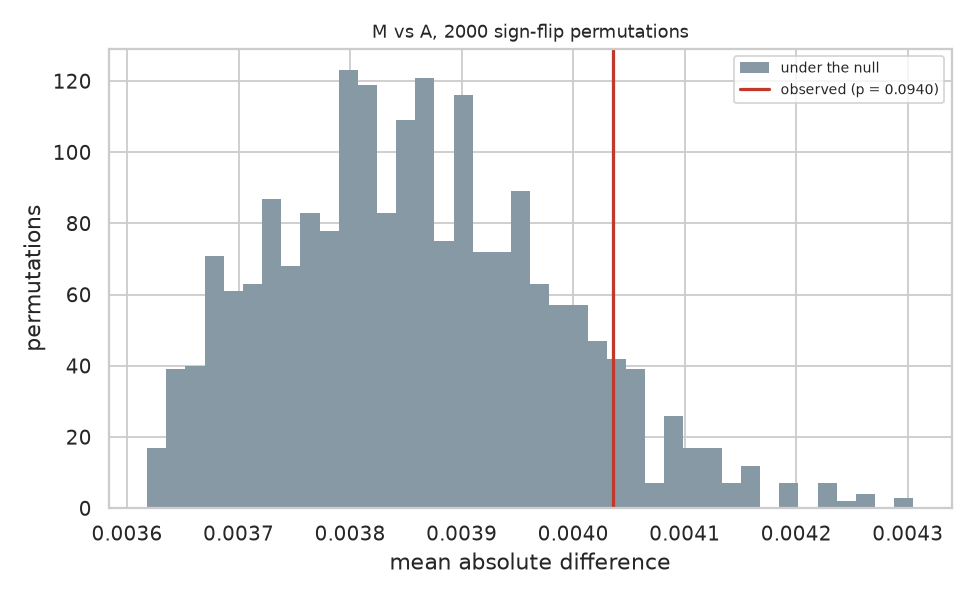

In [ ]:
print("[[step]] r050 start 12/19 ▶ Proving: Permutation Test", flush=True)

# ── Permutation Test ──
from scipy import stats as st
import json as _json

result = {}
method = 'permutation test'
gcol, vcol, ca, cb = '', 'beta', '', ''
_FEAT, _SUBJ, _COND = 'ID', 'subject', 'condition'
_CA, _CB = 'M', 'A'
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'constant', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 2000
_CHROM, _POS = '', ''
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'kruskal-wallis'
_CA_CORR, _CA_MAX, _SAMP = 'bonferroni', 50000, ''

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        vcol = next((c for c in _num_cols if c != gcol), _num_cols[0] if _num_cols else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
elif "ols" in method:
    if not vcol or vcol not in df.columns:
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] r050 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Permutation Test: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("r050__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols = list(_num_df.columns[:12])
            plt.figure(figsize=(7, 4.5))
            plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
            plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
            plt.title("Distribution of numeric columns")
            save_fig("r050__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("r050__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("r050__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("r050__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("r050", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("r050", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("r050", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "r050__component_association.csv", index=False)

                METRICS["r050::samples"] = int(_M.shape[0])
                METRICS["r050::features_used"] = int(_M.shape[1])
                METRICS["r050::components"] = _n
                METRICS["r050::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["r050::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["r050::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("r050", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("r050__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("r050", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r050", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("r050", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("r050", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["r050::clusters"] = _n_clusters
                        METRICS["r050::regions_found"] = _n_regions
                        METRICS["r050::regions_significant"] = _n_pass
                        METRICS["r050::largest_region_area"] = float(_obs_area.max())
                        METRICS["r050::null_threshold"] = _thresh
                        METRICS["r050::permutations"] = _B
                        METRICS["r050::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "r050__regions.csv", index=False)
                            emit_preview("r050", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r050__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("r050", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r050", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("r050", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["r050::features_tested"] = _tot
                        METRICS["r050::equivalent"] = _n_eq
                        METRICS["r050::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["r050::margin"] = _dlt
                        METRICS["r050::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["r050::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["r050::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["r050::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "r050__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r050__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["r050::statistic"] = _obs
                        METRICS["r050::p_value"] = _p
                        METRICS["r050::permutations"] = _B
                        METRICS["r050::null_median"] = float(np.median(_null))
                        METRICS["r050::features"] = int(len(_ft))
                        METRICS["r050::subjects"] = int(len(_sub))
                        METRICS["r050::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r050__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("r050", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r050", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("r050",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "r050__paired_feature_test.csv", index=False)
                    METRICS["r050::features_tested"] = int(len(_shared_feat))
                    METRICS["r050::subjects_paired"] = int(len(_shared_subj))
                    METRICS["r050::significant"] = _sig
                    METRICS["r050::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["r050::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["r050::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("r050__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("r050", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("r050", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r050", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("r050", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("r050", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["r050::limits_shape_a"] = float(_coef[0])
                                METRICS["r050::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["r050::bias"] = _bias
                        METRICS["r050::limit_lower"] = float(_lo)
                        METRICS["r050::limit_upper"] = float(_hi)
                        METRICS["r050::pairs"] = int(len(_va))
                        METRICS["r050::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["r050::normality_shapiro_p"] = _norm_p
                            METRICS["r050::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r050__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = vcol if vcol in df.columns else df.columns[-1]
        Xr = df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore").fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("r050__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["r050::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "r050__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Permutation Test')
    _rep.to_csv(ARTIFACTS / "r050__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Permutation Test:", _summary if _summary else "computed (saved to results)", flush=True)

print("[[step]] r050 done 12/19 ✓ Permutation Test", flush=True)

## Permutation Test

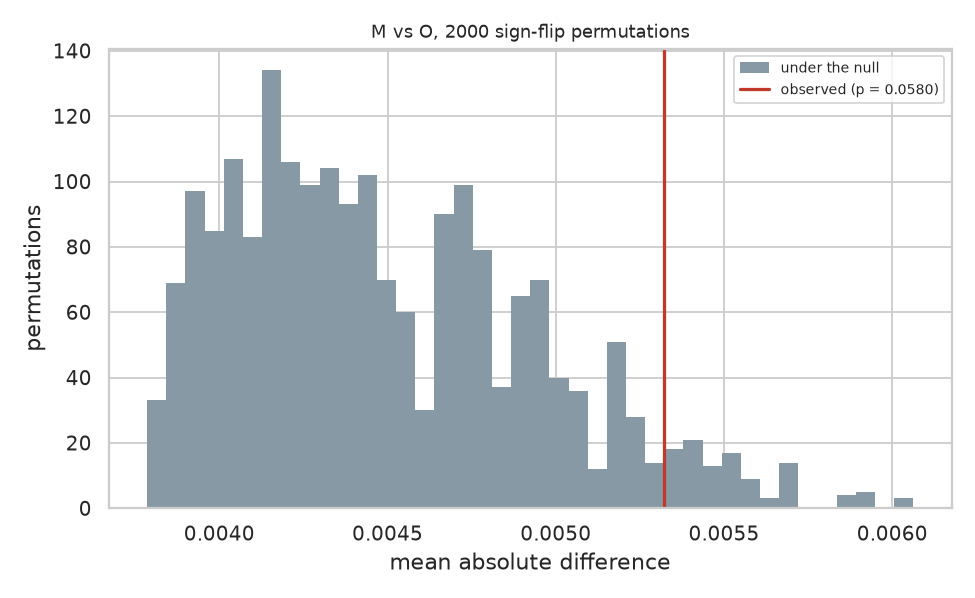

In [ ]:
print("[[step]] r051 start 13/19 ▶ Proving: Permutation Test", flush=True)

# ── Permutation Test ──
from scipy import stats as st
import json as _json

result = {}
method = 'permutation test'
gcol, vcol, ca, cb = '', 'beta', '', ''
_FEAT, _SUBJ, _COND = 'ID', 'subject', 'condition'
_CA, _CB = 'M', 'O'
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'constant', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 2000
_CHROM, _POS = '', ''
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'kruskal-wallis'
_CA_CORR, _CA_MAX, _SAMP = 'bonferroni', 50000, ''

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        vcol = next((c for c in _num_cols if c != gcol), _num_cols[0] if _num_cols else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
elif "ols" in method:
    if not vcol or vcol not in df.columns:
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] r051 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Permutation Test: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("r051__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols = list(_num_df.columns[:12])
            plt.figure(figsize=(7, 4.5))
            plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
            plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
            plt.title("Distribution of numeric columns")
            save_fig("r051__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("r051__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("r051__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("r051__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("r051", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("r051", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("r051", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "r051__component_association.csv", index=False)

                METRICS["r051::samples"] = int(_M.shape[0])
                METRICS["r051::features_used"] = int(_M.shape[1])
                METRICS["r051::components"] = _n
                METRICS["r051::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["r051::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["r051::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("r051", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("r051__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("r051", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r051", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("r051", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("r051", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["r051::clusters"] = _n_clusters
                        METRICS["r051::regions_found"] = _n_regions
                        METRICS["r051::regions_significant"] = _n_pass
                        METRICS["r051::largest_region_area"] = float(_obs_area.max())
                        METRICS["r051::null_threshold"] = _thresh
                        METRICS["r051::permutations"] = _B
                        METRICS["r051::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "r051__regions.csv", index=False)
                            emit_preview("r051", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r051__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("r051", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r051", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("r051", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["r051::features_tested"] = _tot
                        METRICS["r051::equivalent"] = _n_eq
                        METRICS["r051::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["r051::margin"] = _dlt
                        METRICS["r051::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["r051::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["r051::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["r051::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "r051__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r051__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["r051::statistic"] = _obs
                        METRICS["r051::p_value"] = _p
                        METRICS["r051::permutations"] = _B
                        METRICS["r051::null_median"] = float(np.median(_null))
                        METRICS["r051::features"] = int(len(_ft))
                        METRICS["r051::subjects"] = int(len(_sub))
                        METRICS["r051::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r051__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("r051", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r051", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("r051",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "r051__paired_feature_test.csv", index=False)
                    METRICS["r051::features_tested"] = int(len(_shared_feat))
                    METRICS["r051::subjects_paired"] = int(len(_shared_subj))
                    METRICS["r051::significant"] = _sig
                    METRICS["r051::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["r051::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["r051::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("r051__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("r051", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("r051", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r051", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("r051", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("r051", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["r051::limits_shape_a"] = float(_coef[0])
                                METRICS["r051::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["r051::bias"] = _bias
                        METRICS["r051::limit_lower"] = float(_lo)
                        METRICS["r051::limit_upper"] = float(_hi)
                        METRICS["r051::pairs"] = int(len(_va))
                        METRICS["r051::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["r051::normality_shapiro_p"] = _norm_p
                            METRICS["r051::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r051__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = vcol if vcol in df.columns else df.columns[-1]
        Xr = df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore").fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("r051__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["r051::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "r051__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Permutation Test')
    _rep.to_csv(ARTIFACTS / "r051__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Permutation Test:", _summary if _summary else "computed (saved to results)", flush=True)

print("[[step]] r051 done 13/19 ✓ Permutation Test", flush=True)

## Permutation Test

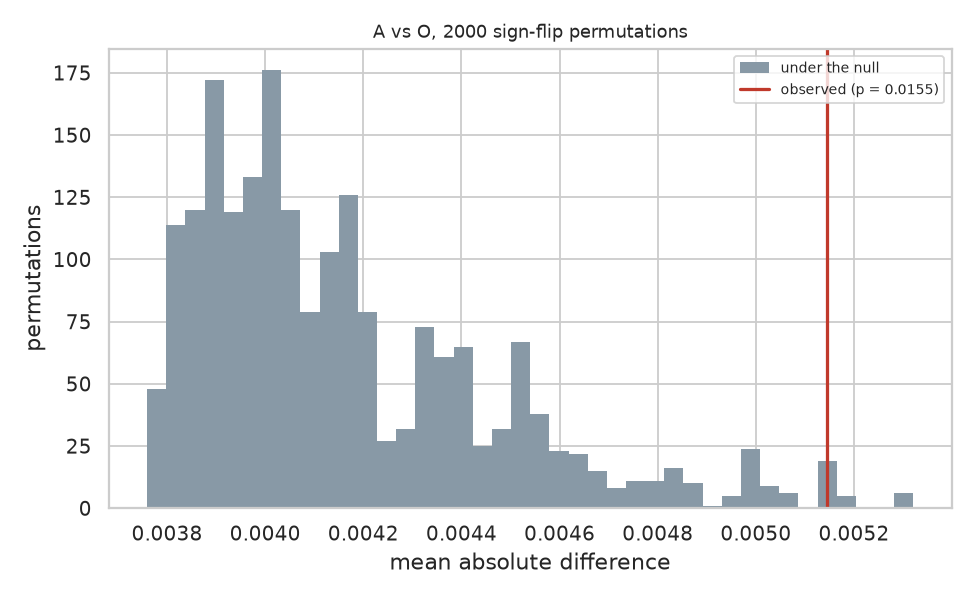

In [ ]:
print("[[step]] r052 start 14/19 ▶ Proving: Permutation Test", flush=True)

# ── Permutation Test ──
from scipy import stats as st
import json as _json

result = {}
method = 'permutation test'
gcol, vcol, ca, cb = '', 'beta', '', ''
_FEAT, _SUBJ, _COND = 'ID', 'subject', 'condition'
_CA, _CB = 'A', 'O'
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'constant', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 2000
_CHROM, _POS = '', ''
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'kruskal-wallis'
_CA_CORR, _CA_MAX, _SAMP = 'bonferroni', 50000, ''

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        vcol = next((c for c in _num_cols if c != gcol), _num_cols[0] if _num_cols else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
elif "ols" in method:
    if not vcol or vcol not in df.columns:
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] r052 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Permutation Test: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("r052__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols = list(_num_df.columns[:12])
            plt.figure(figsize=(7, 4.5))
            plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
            plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
            plt.title("Distribution of numeric columns")
            save_fig("r052__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("r052__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("r052__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("r052__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("r052", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("r052", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("r052", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "r052__component_association.csv", index=False)

                METRICS["r052::samples"] = int(_M.shape[0])
                METRICS["r052::features_used"] = int(_M.shape[1])
                METRICS["r052::components"] = _n
                METRICS["r052::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["r052::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["r052::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("r052", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("r052__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("r052", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r052", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("r052", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("r052", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["r052::clusters"] = _n_clusters
                        METRICS["r052::regions_found"] = _n_regions
                        METRICS["r052::regions_significant"] = _n_pass
                        METRICS["r052::largest_region_area"] = float(_obs_area.max())
                        METRICS["r052::null_threshold"] = _thresh
                        METRICS["r052::permutations"] = _B
                        METRICS["r052::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "r052__regions.csv", index=False)
                            emit_preview("r052", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r052__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("r052", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r052", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("r052", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["r052::features_tested"] = _tot
                        METRICS["r052::equivalent"] = _n_eq
                        METRICS["r052::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["r052::margin"] = _dlt
                        METRICS["r052::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["r052::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["r052::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["r052::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "r052__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r052__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["r052::statistic"] = _obs
                        METRICS["r052::p_value"] = _p
                        METRICS["r052::permutations"] = _B
                        METRICS["r052::null_median"] = float(np.median(_null))
                        METRICS["r052::features"] = int(len(_ft))
                        METRICS["r052::subjects"] = int(len(_sub))
                        METRICS["r052::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r052__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("r052", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r052", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("r052",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "r052__paired_feature_test.csv", index=False)
                    METRICS["r052::features_tested"] = int(len(_shared_feat))
                    METRICS["r052::subjects_paired"] = int(len(_shared_subj))
                    METRICS["r052::significant"] = _sig
                    METRICS["r052::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["r052::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["r052::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("r052__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("r052", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("r052", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r052", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("r052", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("r052", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["r052::limits_shape_a"] = float(_coef[0])
                                METRICS["r052::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["r052::bias"] = _bias
                        METRICS["r052::limit_lower"] = float(_lo)
                        METRICS["r052::limit_upper"] = float(_hi)
                        METRICS["r052::pairs"] = int(len(_va))
                        METRICS["r052::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["r052::normality_shapiro_p"] = _norm_p
                            METRICS["r052::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r052__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = vcol if vcol in df.columns else df.columns[-1]
        Xr = df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore").fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("r052__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["r052::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "r052__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Permutation Test')
    _rep.to_csv(ARTIFACTS / "r052__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Permutation Test:", _summary if _summary else "computed (saved to results)", flush=True)

print("[[step]] r052 done 14/19 ✓ Permutation Test", flush=True)

## Differential Regions

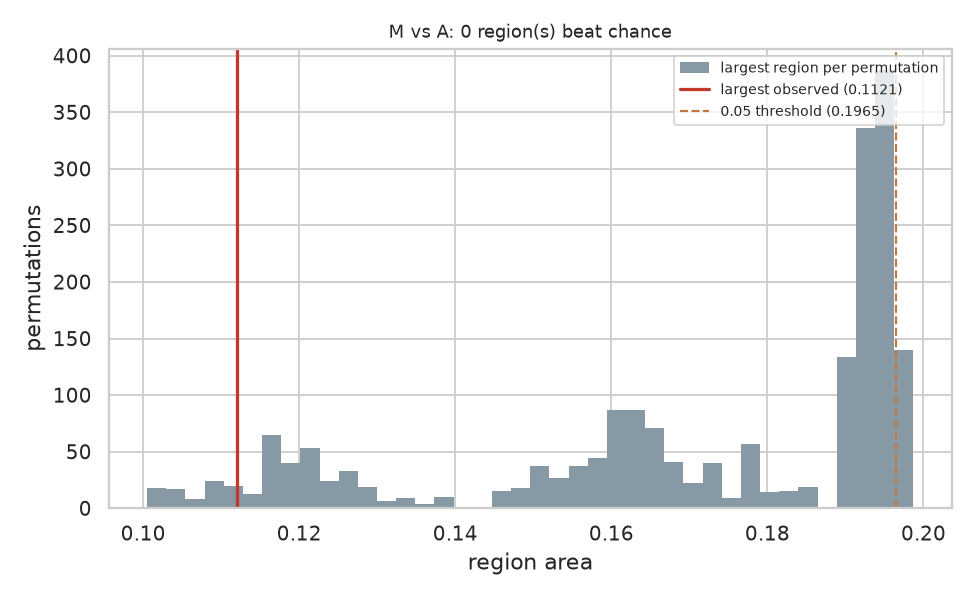

In [ ]:
print("[[step]] r060 start 15/19 ▶ Proving: Differential Regions", flush=True)

# ── Differential Regions ──
from scipy import stats as st
import json as _json

result = {}
method = 'differential regions'
gcol, vcol, ca, cb = '', 'beta', '', ''
_FEAT, _SUBJ, _COND = 'ID', 'subject', 'condition'
_CA, _CB = 'M', 'A'
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'constant', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 2000
_CHROM, _POS = 'Chromosome', 'Start'
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'kruskal-wallis'
_CA_CORR, _CA_MAX, _SAMP = 'bonferroni', 50000, ''

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        vcol = next((c for c in _num_cols if c != gcol), _num_cols[0] if _num_cols else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
elif "ols" in method:
    if not vcol or vcol not in df.columns:
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] r060 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Differential Regions: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("r060__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols = list(_num_df.columns[:12])
            plt.figure(figsize=(7, 4.5))
            plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
            plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
            plt.title("Distribution of numeric columns")
            save_fig("r060__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("r060__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("r060__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("r060__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("r060", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("r060", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("r060", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "r060__component_association.csv", index=False)

                METRICS["r060::samples"] = int(_M.shape[0])
                METRICS["r060::features_used"] = int(_M.shape[1])
                METRICS["r060::components"] = _n
                METRICS["r060::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["r060::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["r060::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("r060", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("r060__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("r060", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r060", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("r060", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("r060", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["r060::clusters"] = _n_clusters
                        METRICS["r060::regions_found"] = _n_regions
                        METRICS["r060::regions_significant"] = _n_pass
                        METRICS["r060::largest_region_area"] = float(_obs_area.max())
                        METRICS["r060::null_threshold"] = _thresh
                        METRICS["r060::permutations"] = _B
                        METRICS["r060::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "r060__regions.csv", index=False)
                            emit_preview("r060", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r060__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("r060", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r060", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("r060", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["r060::features_tested"] = _tot
                        METRICS["r060::equivalent"] = _n_eq
                        METRICS["r060::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["r060::margin"] = _dlt
                        METRICS["r060::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["r060::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["r060::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["r060::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "r060__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r060__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["r060::statistic"] = _obs
                        METRICS["r060::p_value"] = _p
                        METRICS["r060::permutations"] = _B
                        METRICS["r060::null_median"] = float(np.median(_null))
                        METRICS["r060::features"] = int(len(_ft))
                        METRICS["r060::subjects"] = int(len(_sub))
                        METRICS["r060::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r060__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("r060", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r060", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("r060",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "r060__paired_feature_test.csv", index=False)
                    METRICS["r060::features_tested"] = int(len(_shared_feat))
                    METRICS["r060::subjects_paired"] = int(len(_shared_subj))
                    METRICS["r060::significant"] = _sig
                    METRICS["r060::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["r060::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["r060::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("r060__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("r060", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("r060", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r060", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("r060", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("r060", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["r060::limits_shape_a"] = float(_coef[0])
                                METRICS["r060::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["r060::bias"] = _bias
                        METRICS["r060::limit_lower"] = float(_lo)
                        METRICS["r060::limit_upper"] = float(_hi)
                        METRICS["r060::pairs"] = int(len(_va))
                        METRICS["r060::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["r060::normality_shapiro_p"] = _norm_p
                            METRICS["r060::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r060__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = vcol if vcol in df.columns else df.columns[-1]
        Xr = df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore").fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("r060__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["r060::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "r060__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Differential Regions')
    _rep.to_csv(ARTIFACTS / "r060__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Differential Regions:", _summary if _summary else "computed (saved to results)", flush=True)

print("[[step]] r060 done 15/19 ✓ Differential Regions", flush=True)

## Differential Regions

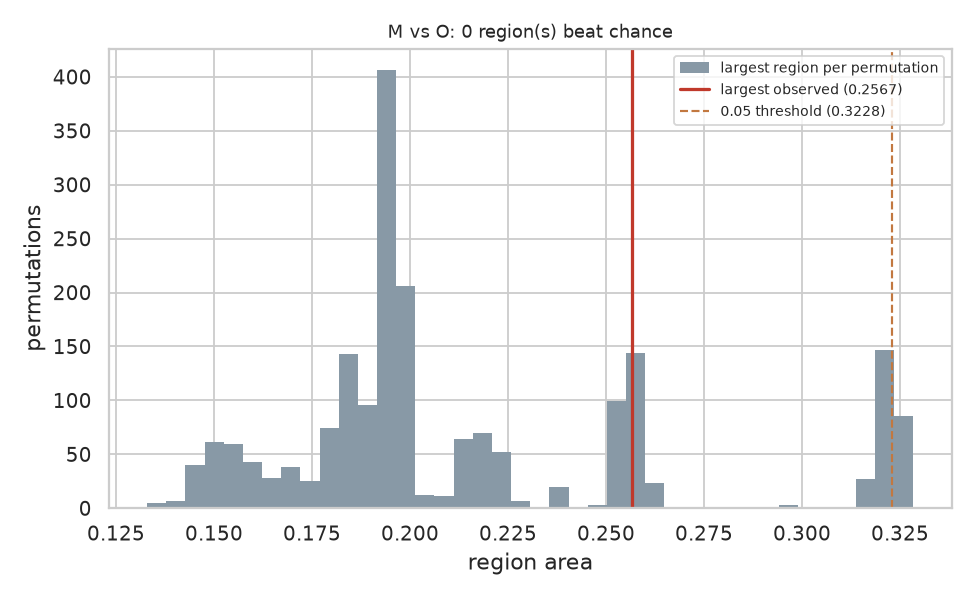

In [ ]:
print("[[step]] r061 start 16/19 ▶ Proving: Differential Regions", flush=True)

# ── Differential Regions ──
from scipy import stats as st
import json as _json

result = {}
method = 'differential regions'
gcol, vcol, ca, cb = '', 'beta', '', ''
_FEAT, _SUBJ, _COND = 'ID', 'subject', 'condition'
_CA, _CB = 'M', 'O'
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'constant', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 2000
_CHROM, _POS = 'Chromosome', 'Start'
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'kruskal-wallis'
_CA_CORR, _CA_MAX, _SAMP = 'bonferroni', 50000, ''

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        vcol = next((c for c in _num_cols if c != gcol), _num_cols[0] if _num_cols else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
elif "ols" in method:
    if not vcol or vcol not in df.columns:
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] r061 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Differential Regions: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("r061__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols = list(_num_df.columns[:12])
            plt.figure(figsize=(7, 4.5))
            plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
            plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
            plt.title("Distribution of numeric columns")
            save_fig("r061__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("r061__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("r061__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("r061__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("r061", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("r061", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("r061", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "r061__component_association.csv", index=False)

                METRICS["r061::samples"] = int(_M.shape[0])
                METRICS["r061::features_used"] = int(_M.shape[1])
                METRICS["r061::components"] = _n
                METRICS["r061::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["r061::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["r061::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("r061", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("r061__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("r061", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r061", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("r061", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("r061", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["r061::clusters"] = _n_clusters
                        METRICS["r061::regions_found"] = _n_regions
                        METRICS["r061::regions_significant"] = _n_pass
                        METRICS["r061::largest_region_area"] = float(_obs_area.max())
                        METRICS["r061::null_threshold"] = _thresh
                        METRICS["r061::permutations"] = _B
                        METRICS["r061::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "r061__regions.csv", index=False)
                            emit_preview("r061", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r061__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("r061", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r061", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("r061", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["r061::features_tested"] = _tot
                        METRICS["r061::equivalent"] = _n_eq
                        METRICS["r061::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["r061::margin"] = _dlt
                        METRICS["r061::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["r061::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["r061::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["r061::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "r061__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r061__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["r061::statistic"] = _obs
                        METRICS["r061::p_value"] = _p
                        METRICS["r061::permutations"] = _B
                        METRICS["r061::null_median"] = float(np.median(_null))
                        METRICS["r061::features"] = int(len(_ft))
                        METRICS["r061::subjects"] = int(len(_sub))
                        METRICS["r061::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r061__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("r061", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r061", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("r061",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "r061__paired_feature_test.csv", index=False)
                    METRICS["r061::features_tested"] = int(len(_shared_feat))
                    METRICS["r061::subjects_paired"] = int(len(_shared_subj))
                    METRICS["r061::significant"] = _sig
                    METRICS["r061::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["r061::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["r061::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("r061__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("r061", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("r061", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r061", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("r061", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("r061", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["r061::limits_shape_a"] = float(_coef[0])
                                METRICS["r061::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["r061::bias"] = _bias
                        METRICS["r061::limit_lower"] = float(_lo)
                        METRICS["r061::limit_upper"] = float(_hi)
                        METRICS["r061::pairs"] = int(len(_va))
                        METRICS["r061::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["r061::normality_shapiro_p"] = _norm_p
                            METRICS["r061::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r061__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = vcol if vcol in df.columns else df.columns[-1]
        Xr = df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore").fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("r061__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["r061::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "r061__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Differential Regions')
    _rep.to_csv(ARTIFACTS / "r061__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Differential Regions:", _summary if _summary else "computed (saved to results)", flush=True)

print("[[step]] r061 done 16/19 ✓ Differential Regions", flush=True)

## Differential Regions

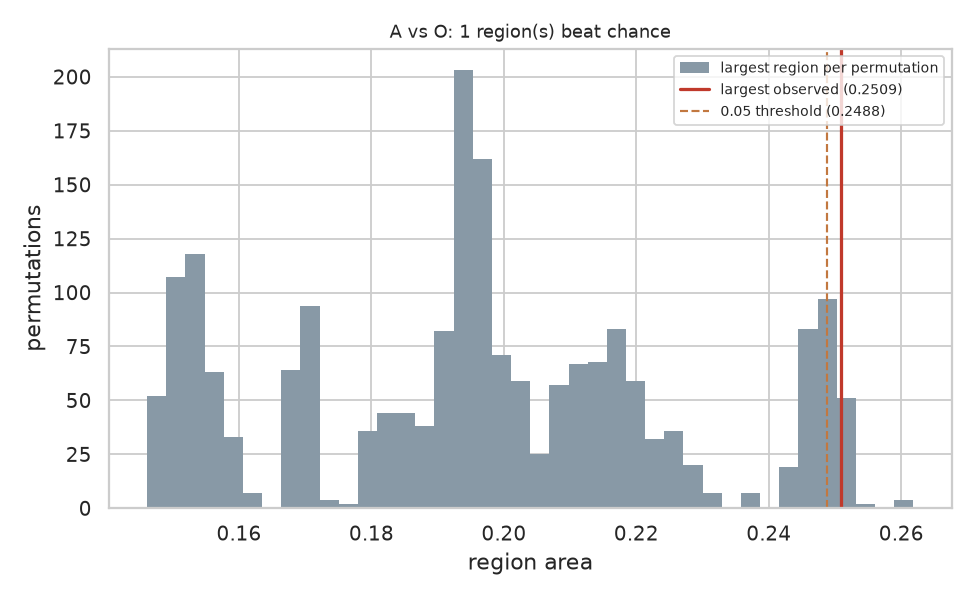

In [ ]:
print("[[step]] r062 start 17/19 ▶ Proving: Differential Regions", flush=True)

# ── Differential Regions ──
from scipy import stats as st
import json as _json

result = {}
method = 'differential regions'
gcol, vcol, ca, cb = '', 'beta', '', ''
_FEAT, _SUBJ, _COND = 'ID', 'subject', 'condition'
_CA, _CB = 'A', 'O'
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'constant', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 2000
_CHROM, _POS = 'Chromosome', 'Start'
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'kruskal-wallis'
_CA_CORR, _CA_MAX, _SAMP = 'bonferroni', 50000, ''

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        vcol = next((c for c in _num_cols if c != gcol), _num_cols[0] if _num_cols else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
elif "ols" in method:
    if not vcol or vcol not in df.columns:
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] r062 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Differential Regions: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("r062__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols = list(_num_df.columns[:12])
            plt.figure(figsize=(7, 4.5))
            plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
            plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
            plt.title("Distribution of numeric columns")
            save_fig("r062__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("r062__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("r062__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("r062__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("r062", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("r062", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("r062", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "r062__component_association.csv", index=False)

                METRICS["r062::samples"] = int(_M.shape[0])
                METRICS["r062::features_used"] = int(_M.shape[1])
                METRICS["r062::components"] = _n
                METRICS["r062::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["r062::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["r062::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("r062", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("r062__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("r062", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r062", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("r062", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("r062", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["r062::clusters"] = _n_clusters
                        METRICS["r062::regions_found"] = _n_regions
                        METRICS["r062::regions_significant"] = _n_pass
                        METRICS["r062::largest_region_area"] = float(_obs_area.max())
                        METRICS["r062::null_threshold"] = _thresh
                        METRICS["r062::permutations"] = _B
                        METRICS["r062::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "r062__regions.csv", index=False)
                            emit_preview("r062", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r062__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("r062", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r062", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("r062", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["r062::features_tested"] = _tot
                        METRICS["r062::equivalent"] = _n_eq
                        METRICS["r062::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["r062::margin"] = _dlt
                        METRICS["r062::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["r062::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["r062::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["r062::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "r062__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r062__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["r062::statistic"] = _obs
                        METRICS["r062::p_value"] = _p
                        METRICS["r062::permutations"] = _B
                        METRICS["r062::null_median"] = float(np.median(_null))
                        METRICS["r062::features"] = int(len(_ft))
                        METRICS["r062::subjects"] = int(len(_sub))
                        METRICS["r062::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r062__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("r062", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r062", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("r062",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "r062__paired_feature_test.csv", index=False)
                    METRICS["r062::features_tested"] = int(len(_shared_feat))
                    METRICS["r062::subjects_paired"] = int(len(_shared_subj))
                    METRICS["r062::significant"] = _sig
                    METRICS["r062::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["r062::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["r062::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("r062__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("r062", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("r062", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r062", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("r062", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("r062", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["r062::limits_shape_a"] = float(_coef[0])
                                METRICS["r062::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["r062::bias"] = _bias
                        METRICS["r062::limit_lower"] = float(_lo)
                        METRICS["r062::limit_upper"] = float(_hi)
                        METRICS["r062::pairs"] = int(len(_va))
                        METRICS["r062::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["r062::normality_shapiro_p"] = _norm_p
                            METRICS["r062::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r062__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = vcol if vcol in df.columns else df.columns[-1]
        Xr = df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore").fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("r062__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["r062::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "r062__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Differential Regions')
    _rep.to_csv(ARTIFACTS / "r062__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Differential Regions:", _summary if _summary else "computed (saved to results)", flush=True)

print("[[step]] r062 done 17/19 ✓ Differential Regions", flush=True)

## Component Association

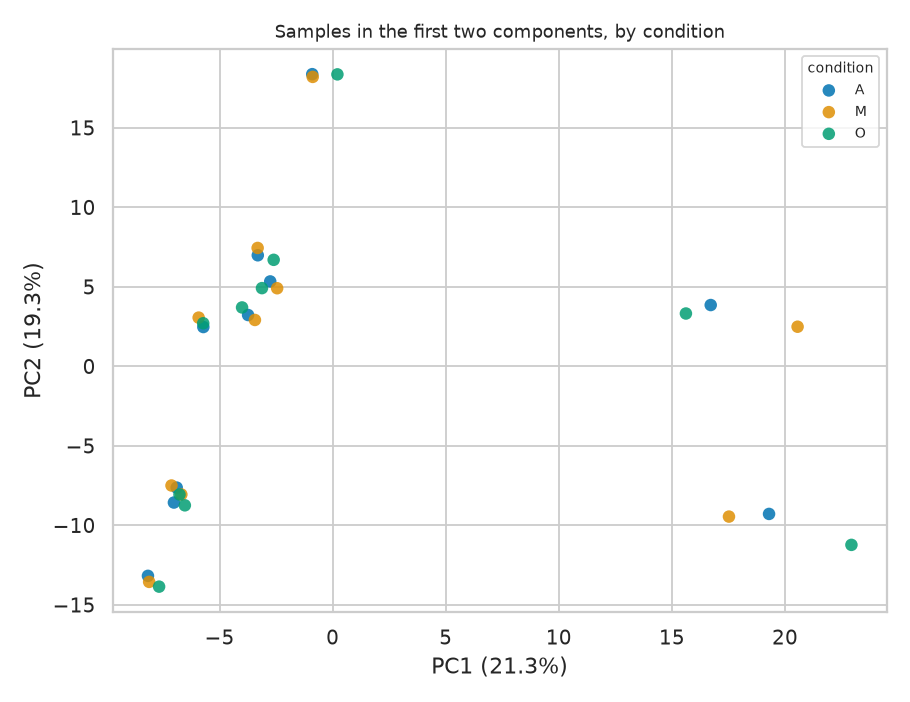

In [ ]:
print("[[step]] r070 start 18/19 ▶ Proving: Component Association", flush=True)

# ── Component Association ──
from scipy import stats as st
import json as _json

result = {}
method = 'component association'
gcol, vcol, ca, cb = '', 'beta', '', ''
_FEAT, _SUBJ, _COND = 'ID', '', ''
_CA, _CB = '', ''
_PTEST, _CORR = 'kruskal-wallis', 'bonferroni'
_BA_LIMITS, _BA_POINTS = 'constant', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 1000
_CHROM, _POS = '', ''
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = ['condition', 'subject'], 10, 'kruskal-wallis'
_CA_CORR, _CA_MAX, _SAMP = 'bonferroni', 50000, 'sample'

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        vcol = next((c for c in _num_cols if c != gcol), _num_cols[0] if _num_cols else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
elif "ols" in method:
    if not vcol or vcol not in df.columns:
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] r070 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Component Association: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("r070__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols = list(_num_df.columns[:12])
            plt.figure(figsize=(7, 4.5))
            plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
            plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
            plt.title("Distribution of numeric columns")
            save_fig("r070__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("r070__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("r070__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("r070__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("r070", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("r070", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("r070", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "r070__component_association.csv", index=False)

                METRICS["r070::samples"] = int(_M.shape[0])
                METRICS["r070::features_used"] = int(_M.shape[1])
                METRICS["r070::components"] = _n
                METRICS["r070::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["r070::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["r070::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("r070", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("r070__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("r070", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r070", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("r070", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("r070", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["r070::clusters"] = _n_clusters
                        METRICS["r070::regions_found"] = _n_regions
                        METRICS["r070::regions_significant"] = _n_pass
                        METRICS["r070::largest_region_area"] = float(_obs_area.max())
                        METRICS["r070::null_threshold"] = _thresh
                        METRICS["r070::permutations"] = _B
                        METRICS["r070::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "r070__regions.csv", index=False)
                            emit_preview("r070", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r070__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("r070", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r070", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("r070", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["r070::features_tested"] = _tot
                        METRICS["r070::equivalent"] = _n_eq
                        METRICS["r070::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["r070::margin"] = _dlt
                        METRICS["r070::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["r070::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["r070::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["r070::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "r070__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r070__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["r070::statistic"] = _obs
                        METRICS["r070::p_value"] = _p
                        METRICS["r070::permutations"] = _B
                        METRICS["r070::null_median"] = float(np.median(_null))
                        METRICS["r070::features"] = int(len(_ft))
                        METRICS["r070::subjects"] = int(len(_sub))
                        METRICS["r070::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r070__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("r070", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r070", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("r070",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "r070__paired_feature_test.csv", index=False)
                    METRICS["r070::features_tested"] = int(len(_shared_feat))
                    METRICS["r070::subjects_paired"] = int(len(_shared_subj))
                    METRICS["r070::significant"] = _sig
                    METRICS["r070::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["r070::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["r070::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("r070__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("r070", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("r070", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("r070", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("r070", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("r070", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["r070::limits_shape_a"] = float(_coef[0])
                                METRICS["r070::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["r070::bias"] = _bias
                        METRICS["r070::limit_lower"] = float(_lo)
                        METRICS["r070::limit_upper"] = float(_hi)
                        METRICS["r070::pairs"] = int(len(_va))
                        METRICS["r070::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["r070::normality_shapiro_p"] = _norm_p
                            METRICS["r070::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("r070__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = vcol if vcol in df.columns else df.columns[-1]
        Xr = df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore").fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("r070__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["r070::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "r070__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Component Association')
    _rep.to_csv(ARTIFACTS / "r070__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Component Association:", _summary if _summary else "computed (saved to results)", flush=True)

print("[[step]] r070 done 18/19 ✓ Component Association", flush=True)

## Report

In [ ]:
print("[[step]] r030 start 19/19 ▶ Sealing: Report", flush=True)

# ── Report ──
# What the report will be written from. The report itself is assembled after
# the run, from the metrics and figures collected here, so this step's honest
# answer is an inventory: how much evidence there is, and from which steps.
# An empty inventory is the useful case -- it says the report will be thin and
# why, before anybody opens it and wonders.
_figs = sorted(p.name for p in ARTIFACTS.glob("*.png"))
_tabs = sorted(p.name for p in ARTIFACTS.glob("*.csv"))
_steps = sorted({k.split("::", 1)[0] for k in METRICS if "::" in k})
METRICS["r030::figures"] = len(_figs)
METRICS["r030::tables"] = len(_tabs)
METRICS["r030::measurements"] = len(METRICS)
METRICS["r030::steps_reporting"] = len(_steps)
METRICS["r030::template"] = 'academic'
METRICS["r030::include_plots"] = True
if not _figs and not _tabs:
    METRICS["r030::contents"] = ("nothing yet: no step before this one produced "
                                  "a figure or a table")
    print("Report: no figures or tables were produced by the steps before this "
          "one, so the report will hold the run's settings and little else",
          flush=True)
else:
    _plural = lambda n, w: "%d %s%s" % (n, w, "" if n == 1 else "s")
    METRICS["r030::contents"] = "%s and %s from %s" % (
        _plural(len(_figs), "figure"), _plural(len(_tabs), "table"),
        _plural(len(_steps), "step"))
    print("Report: %s will go into the report"
          % METRICS["r030::contents"], flush=True)
pd.DataFrame(
    [{"kind": "figure", "file": f} for f in _figs]
    + [{"kind": "table", "file": t} for t in _tabs]
).to_csv(ARTIFACTS / "r030__report_contents.csv", index=False)

print("[[step]] r030 done 19/19 ✓ Report", flush=True)

## Finalize

In [ ]:
with open(ARTIFACTS / "metrics.json", "w") as f:
    json.dump(METRICS, f, indent=2)
print("pipeline finished")

## Run output

In [ ]:
# captured stdout (tail)

: 323248, 'of': 440110, 'margin': 0.02}
[[step]] r041 done 10/19 ✓ Equivalence Test
[[step]] r042 start 11/19 ▶ Proving: Equivalence Test
A vs O: 337176 of 440110 equivalent within +/-0.02 (76.6%)
this design could detect a difference of about 0.0124 per feature (0.0626 after correcting for 440110 tests); the median difference observed is 0.0028
the remaining 102934 were not SHOWN to differ either; they are the features this sample cannot decide
    Equivalence Test: {'equivalent': 337176, 'of': 440110, 'margin': 0.02}
[[step]] r042 done 11/19 ✓ Equivalence Test
[[step]] r050 start 12/19 ▶ Proving: Permutation Test
M vs A: mean-absolute-difference = 0.004036 across 440110 features and 10 paired subjects; p = 0.0940 from 2000 sign-flip permutations
a shift shared by every feature is invisible to testing them one at a time, which is what this looks for and a per-feature test cannot see
    Permutation Test: {'statistic': 0.004036084174497216, 'p_value': 0.09395302348825588, 'permutations

## Metrics
```json
{
  "input_rows": 440110,
  "input_columns": 35,
  "r002::rows_after_reshape": 13203300,
  "r002::melted_columns": 30,
  "r002::headers_parsed": 13203300,
  "r010::limits_shape_a": -3.7328675269160008,
  "r010::limits_shape_b": -8.56852806987727,
  "r010::bias": -0.0008978767987005001,
  "r010::limit_lower": -0.03799981564780516,
  "r010::limit_upper": 0.03620406205040416,
  "r010::pairs": 4401100,
  "r010::comparison": "M vs A",
  "r010::normality_shapiro_p": 2.405060774845165e-56,
  "r010::normality_shapiro_tests": "normality of the paired differences, NOT a difference between the two methods. A small p means the differences are not normally distributed, so constant limits of agreement would misdescribe the spread and proportional limits are used instead.",
  "method agreement::bias": -0.0006133845323319175,
  "method agreement::pairs": 4401100,
  "r011::limits_shape_a": -3.5513961041783673,
  "r011::limits_shape_b": -8.964555636869601,
  "r011::bias": -0.0015112613310324175,
  "r011::limit_lower": -0.046028404371155164,
  "r011::limit_upper": 0.04300588170909033,
  "r011::pairs": 4401100,
  "r011::comparison": "M vs O",
  "r011::normality_shapiro_p": 1.4711476478735496e-58,
  "r011::normality_shapiro_tests": "normality of the paired differences, NOT a difference between the two methods. A small p means the differences are not normally distributed, so constant limits of agreement would misdescribe the spread and proportional limits are used instead.",
  "r012::limits_shape_a": -3.643099527624665,
  "r012::limits_shape_b": -8.745394191904312,
  "r012::bias": -0.0006133845323319175,
  "r012::limit_lower": -0.04113937774137014,
  "r012::limit_upper": 0.039912608676706304,
  "r012::pairs": 4401100,
  "r012::comparison": "A vs O",
  "r012::normality_shapiro_p": 4.9576789195142105e-59,
  "r012::normality_shapiro_tests": "normality of the paired differences, NOT a difference between the two methods. A small p means the differences are not normally distributed, so constant limits of agreement would misdescribe the spread and proportional limits are used instead.",
  "r020::features_tested": 440110,
  "r020::subjects_paired": 10,
  "r020::significant": 0,
  "r020::comparison": "M vs A",
  "r020::smallest_p": 4.7425718050702704e-07,
  "r020::detection_limit": 0.06004020685291982,
  "paired feature test::features_tested": 440110,
  "paired feature test::subjects_paired": 10,
  "paired feature test::significant": 0,
  "r021::features_tested": 440110,
  "r021::subjects_paired": 10,
  "r021::significant": 0,
  "r021::comparison": "M vs O",
  "r021::smallest_p": 2.4620226211716894e-06,
  "r021::detection_limit": 0.0658708305152165,
  "r022::features_tested": 440110,
  "r022::subjects_paired": 10,
  "r022::significant": 0,
  "r022::comparison": "A vs O",
  "r022::smallest_p": 1.76178096926783e-06,
  "r022::detection_limit": 0.06257417219427355,
  "r040::features_tested": 440110,
  "r040::equivalent": 360594,
  "r040::equivalent_share": 0.8193269864352094,
  "r040::margin": 0.02,
  "r040::median_observed_difference": 0.002467576500000002,
  "r040::detection_limit": 0.011899521076160928,
  "r040::detection_limit_corrected": 0.06004020685291982,
  "r040::comparison": "M vs A",
  "equivalence test::equivalent": 337176,
  "equivalence test::of": 440110,
  "r040::of": 440110,
  "equivalence test::margin": 0.02,
  "r041::features_tested": 440110,
  "r041::equivalent": 323248,
  "r041::equivalent_share": 0.7344709277226148,
  "r041::margin": 0.02,
  "r041::median_observed_difference": 0.0029691999999999926,
  "r041::detection_limit": 0.013055107187425098,
  "r041::detection_limit_corrected": 0.0658708305152165,
  "r041::comparison": "M vs O",
  "r041::of": 440110,
  "r042::features_tested": 440110,
  "r042::equivalent": 337176,
  "r042::equivalent_share": 0.7661175615187112,
  "r042::margin": 0.02,
  "r042::median_observed_difference": 0.0028342044563272233,
  "r042::detection_limit": 0.012401734102501186,
  "r042::detection_limit_corrected": 0.06257417219427355,
  "r042::comparison": "A vs O",
  "r042::of": 440110,
  "r050::statistic": 0.004036084174497216,
  "r050::p_value": 0.09395302348825588,
  "r050::permutations": 2000,
  "r050::null_median": 0.00385124903445319,
  "r050::features": 440110,
  "r050::subjects": 10,
  "r050::comparison": "M vs A",
  "permutation test::statistic": 0.005144716154079775,
  "permutation test::p_value": 0.015492253873063468,
  "permutation test::permutations": 2000,
  "permutation test::significant_at_0.05": true,
  "r050::significant_at_0.05": false,
  "r051::statistic": 0.005321717871850425,
  "r051::p_value": 0.057971014492753624,
  "r051::permutations": 2000,
  "r051::null_median": 0.004395221960635422,
  "r051::features": 440110,
  "r051::subjects": 10,
  "r051::comparison": "M vs O",
  "r051::significant_at_0.05": false,
  "r052::statistic": 0.005144716154079775,
  "r052::p_value": 0.015492253873063468,
  "r052::permutations": 2000,
  "r052::null_median": 0.0040665726174453085,
  "r052::features": 440110,
  "r052::subjects": 10,
  "r052::comparison": "A vs O",
  "r052::significant_at_0.05": true,
  "r060::clusters": 153239,
  "r060::regions_found": 39697,
  "r060::regions_significant": 0,
  "r060::largest_region_area": 0.1120525868536647,
  "r060::null_threshold": 0.1964944676,
  "r060::permutations": 2000,
  "r060::comparison": "M vs A",
  "differential regions::regions_found": 63501,
  "differential regions::regions_significant": 1,
  "r061::clusters": 153239,
  "r061::regions_found": 67169,
  "r061::regions_significant": 0,
  "r061::largest_region_area": 0.25668083999999997,
  "r061::null_threshold": 0.322847085,
  "r061::permutations": 2000,
  "r061::comparison": "M vs O",
  "r062::clusters": 153239,
  "r062::regions_found": 63501,
  "r062::regions_significant": 1,
  "r062::largest_region_area": 0.25091702,
  "r062::null_threshold": 0.24884444000000006,
  "r062::permutations": 2000,
  "r062::comparison": "A vs O",
  "r070::samples": 30,
  "r070::features_used": 50000,
  "r070::components": 10,
  "r070::variance_pc1": 0.2125917648074832,
  "r070::associated_condition": 0,
  "r070::smallest_p_condition": 0.03286050261086112,
  "r070::associated_subject": 9,
  "r070::smallest_p_subject": 0.0007162719964113468,
  "component association::samples": 30,
  "component association::components": 10,
  "component association::factors_tested": 2,
  "r070::factors_tested": 2,
  "r030::figures": 16,
  "r030::tables": 26,
  "r030::measurements": 150,
  "r030::steps_reporting": 23,
  "r030::template": "academic",
  "r030::include_plots": true,
  "r030::contents": "16 figures and 26 tables from 23 steps"
}
```